In [1]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from datetime import datetime
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu
from smooth_POD_ROM.reduced_order_model import train_ROM_rw, get_predictions, get_predictions_gpu, get_improvement, L2_error_rw
from smooth_POD_ROM.pre_processing import (
    on_regular_grid, _gauss_2d, to_frequency, to_space, add_padding)
from smooth_POD_ROM.post_processing import sharpen, richardson_lucy, get_sigma
#from smooth_POD_ROM.io import get_data, get_field
#from smooth_POD_ROM.plotting import plot_mesh, plot_field, plot_structured_field
from copy import deepcopy
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener, convolve2d
from skimage import restoration
from skimage.restoration import richardson_lucy
#import tvtk
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import cv2
from datetime import datetime
from os import listdir
from os.path import isfile, join
import re

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
single_column_figure = (single_column_in, single_column_in/1.618)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
pth_server_dbCoarseVTU = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results/"
pth_local_dbCoarseOLD = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak/"
pth_local_dbCoarse = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakCoarse/"
pth_local_dbFine = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakFine/"
rank = 80
size_p_test = 20
timestep = 0.25
apply_threshold = False


n_x = n_y = 512
x = np.linspace(0, 0.584, n_x, endpoint=True)
y = np.linspace(0, 0.584, n_y, endpoint=True)
X, Y = np.meshgrid(x, y, indexing="ij")
is_wall = (0.292 <= X) & (X <= 0.316) & (Y <= 0.048)


case = {
    "sigma": 0.013,
    "c": 1,
    "num_iter": 10,
    "shape": X.shape,
    "x": x,  # for truncation of kernel and calculation of sgm
    "dx": x[1]-x[0],  # for truncation of kernel and calculation of sgm
    "mode": 'reflect'
}

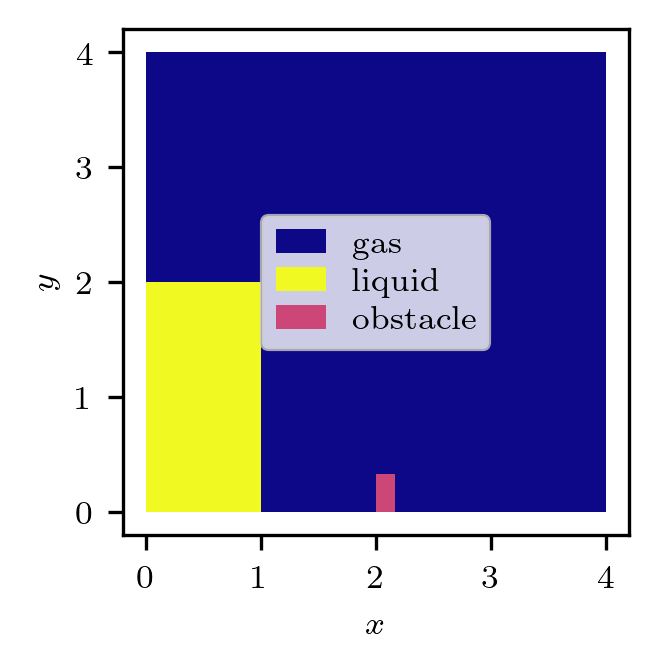

In [4]:
domain = np.array([
    [0, 0, 0],
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
    [4, 0, 0],
    [4, 4, 0],
    [0, 4, 0],
])
water = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [1, 2, 0],
    [0, 2, 0],
])
obstacle = np.array([
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
])

c0 = rgb2hex(cmap(0), keep_alpha=True)
c5 = rgb2hex(cmap(0.5), keep_alpha=True)
c1 = rgb2hex(cmap(1.0), keep_alpha=True)

fig, ax = plt.subplots()
plt.fill(domain[:, 0], domain[:, 1], c0, alpha=1, label="gas")
plt.fill(water[:, 0], water[:, 1], c1, alpha=1, label="liquid")
plt.fill(obstacle[:, 0], obstacle[:, 1], c5, alpha=1, label="obstacle")
ax.set_aspect("equal")
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
#plt.xlim([0, 4])
#plt.ylim([0, 4])
plt.legend()
plt.savefig(pth+"/db_domain.pdf")
plt.show()

In [5]:
def plot_dam_snapshot(ax, ss, X, Y):
    cmap = plt.cm.viridis_r
    #cmap.set_under('C3')
    x = np.unique(X)
    dx = x[1]-x[0]
    y = np.unique(Y)
    dx = y[1]-y[0]
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dx/2, np.max(y)+dx/2)
    cs = ax.imshow(ss.T, origin="lower", interpolation="linear", extent=extent, cmap=cmap, vmin=0, vmax=1)
    return cs

def get_field(file, n='alpha.water'):
    assert isfile(file), file+" is not a valid file name."
    if file.endswith(".vtu"):
        reader = vtk.vtkXMLUnstructuredGridReader()
        reader.SetFileName(file)
    else:
        reader = vtk.vtkGenericDataObjectReader()
        reader.SetFileName(file)
        reader.ReadAllScalarsOn()
        reader.ReadAllVectorsOn()
    reader.Update()

    data = reader.GetOutput()
    if n == "points":
        array = data.GetPoints().GetData()
    else:
        point_data = data.GetPointData()
        array = point_data.GetArray(n)
    return vtk_to_numpy(array)

def get_data(pth, nu_all, rho_all, timesteps=np.linspace(0.01, 1, 100)):
    if len(nu_all) == 0:
        return np.empty((100, 0)), np.empty((0, 2)), np.empty((0, 0))
    X = []
    params = []
    for n, r in zip(nu_all, rho_all):
        for ts in timesteps:
            file = "damBreak_m{:02.1f}_r{:02.1f}_t{:.2f}/internal.vtu".format(n, r, ts)
            file = "res_m{:04.4f}_r{:04.4f}_t{:.2f}/internal.vtu".format(n, r, ts)
            data = get_field(pth+file, 'alpha.water')
            X.append(data)
            params.append([n, r, ts])
    if len(timesteps) == 1:
        params = np.array(params)[:, :2]
    snapshots3D = np.array(X).T
    
    points3D = get_field(pth+file, 'points')
    forbidden_points = points3D[:, 2] > 0.0
    snapshots = snapshots3D[~forbidden_points, :]
    points = points3D[~forbidden_points, :2]
    return snapshots, params, points

In [6]:
# the training data is defined on a regular grid defined as:
nu_grid_c = 10*2**np.arange(0, 10, 1)
rho_grid_c = 10*2**np.arange(0, 8, 1)
nu_train_c, rho_train_c = np.meshgrid(nu_grid_c, rho_grid_c, indexing="ij")
nu_train_c, rho_train_c = nu_train_c.ravel(), rho_train_c.ravel()

In [7]:
ts = timestep
pth = pth_local_dbFine  # pth_local_dbCoarseOLD
print(pth+"t{:.2f}_mu_train.npy".format(ts))
mu_train = np.load(pth+"t{:.2f}_mu_train.npy".format(ts))
X_train = np.load(pth+"t{:.2f}_X_train.npy".format(ts)).T

mu_test = np.load(pth+"t{:.2f}_mu_test.npy".format(ts))
X_test = np.load(pth+"t{:.2f}_X_test.npy".format(ts)).T

#mu_val = np.load(pth+"t{:.2f}_mu_val.npy".format(ts))
#X_val = np.load(pth+"t{:.2f}_X_val.npy".format(ts)).T

points = np.load(pth+"points.npy")
print(points.shape, X_train.shape, mu_train.shape)
n_ss = len(X_train)

C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakFine/t0.25_mu_train.npy
(36705, 2) (224, 36705) (224, 2)


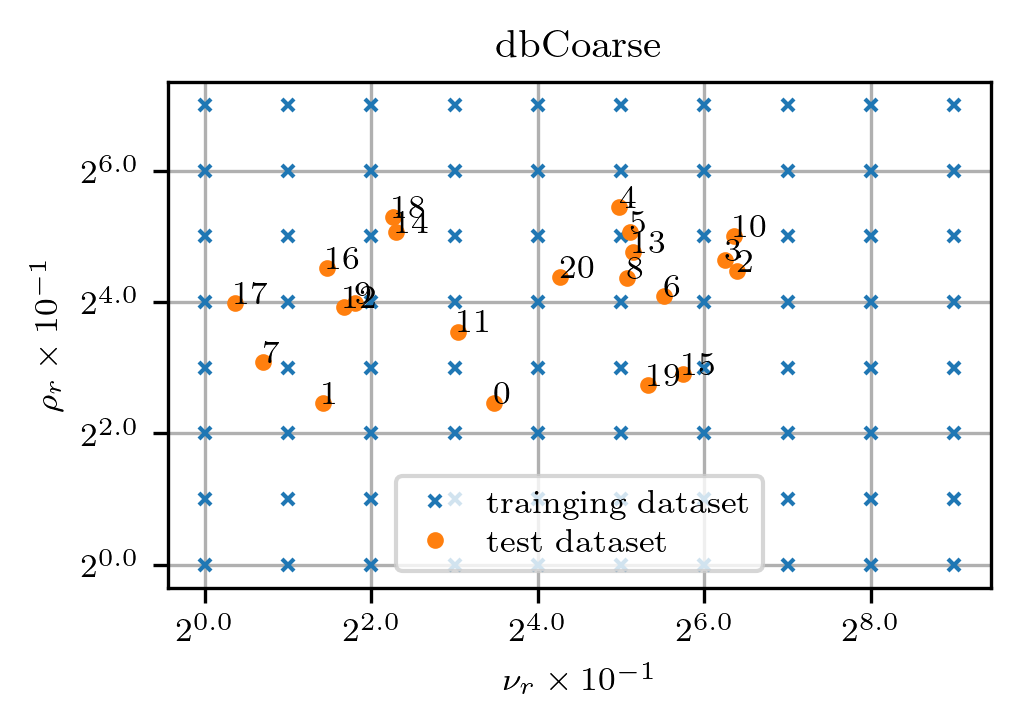

In [8]:
fig, ax = plt.subplots()
nu_test, rho_test = np.split(mu_test, 2, axis=-1)
#nu_val, rho_val = np.split(mu_val, 2, axis=-1)
plt.plot(nu_train_c, rho_train_c, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")
plt.plot(nu_test, rho_test, lw=0.0, color='C1', marker='o', ms=3, label="test dataset")
#plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid_c))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid_c))
ax.set_xticklabels(nu_grid_c)
ax.set_yticklabels(rho_grid_c)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid_c)
ax.set_yticks(rho_grid_c)
ax.set_xticklabels([r'$2^{'+'{:.1f}'.format(e)+'}$' for e in np.log2(ax.get_xticks()/10)])
ax.set_yticklabels([r'$2^{'+'{:.1f}'.format(e)+'}$' for e in np.log2(ax.get_yticks()/10)])
ax.set_xticks(ax.get_xticks()[::2])
ax.set_yticks(ax.get_yticks()[::2])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)
for i in range(len(nu_test)):
    ax.text(nu_test[i], rho_test[i], str(i))
ax.legend()
plt.grid(True)  # print(sgm, sz, ns)
plt.title("dbCoarse")
plt.savefig(pth+"/db_datasets.pdf")
plt.show()

In [9]:
#X, Y, test_snapshot = on_regular_grid(points,  u_train[:, 0])
#m, n = u_train.shape


X_train_grid = np.empty((len(X_train), n_x*n_y))
X_test_grid = np.empty((len(X_test), n_x*n_y))
#X_val_grid = np.empty((len(X_val), n_x*n_y))

for u_set, u_set_grid in zip([X_train, X_test], [X_train_grid, X_test_grid]):
    print(points.shape, u_set.shape)
    gridded = griddata(points[:, :2], u_set.T, (X, Y), method="linear")
    failed = np.isnan(gridded)
    gridded[failed] = griddata(points[:, :2], u_set.T, (X, Y), method="nearest")[failed]
    u_set_grid[:] = gridded.reshape((n_x*n_y, len(u_set))).T
#     for j in range(len(u_set)):
#         gridded = griddata(points[:, :2], u_set[j], (X, Y), method="linear")
# #        if apply_threshold:
# #            gridded = threshold(gridded)
# #        gridded[is_wall] = 0.5
#         u_set_grid[j] = gridded.ravel()
gridded_shape = (n_x, n_y)

(36705, 2) (224, 36705)
(36705, 2) (21, 36705)


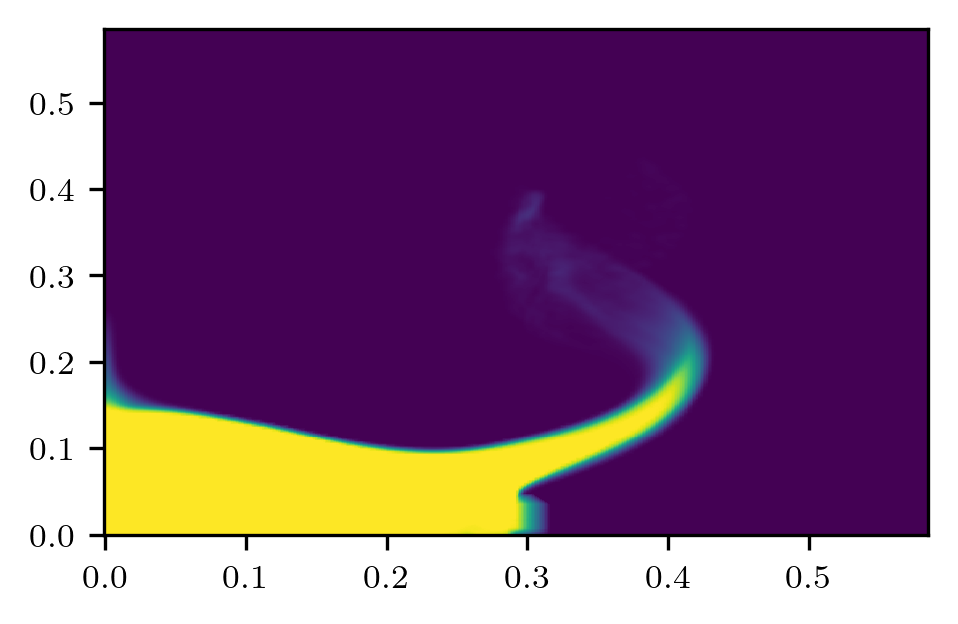

In [10]:
fig,ax = plt.subplots()
ax.pcolormesh(X, Y, np.mean(X_train_grid, axis=0).reshape(case["shape"]))
plt.show()

In [11]:
X_train_grid_s = np.empty_like(X_train_grid)
X_test_grid_s = np.empty_like(X_test_grid)
#X_val_grid_s = np.empty_like(X_val_grid)

sgm = case["sigma"] / case["dx"]
mode = case["mode"]
for X_set_grd, X_set_grd_s in zip([X_train_grid, X_test_grid], [X_train_grid_s, X_test_grid_s]):
    for j in range(len(X_set_grd)):
        ss2D = X_set_grd[j].reshape(case["shape"])
        X_set_grd_s[j] = gaussian_filter(ss2D, sigma=sgm, truncate=10, mode='reflect').ravel()

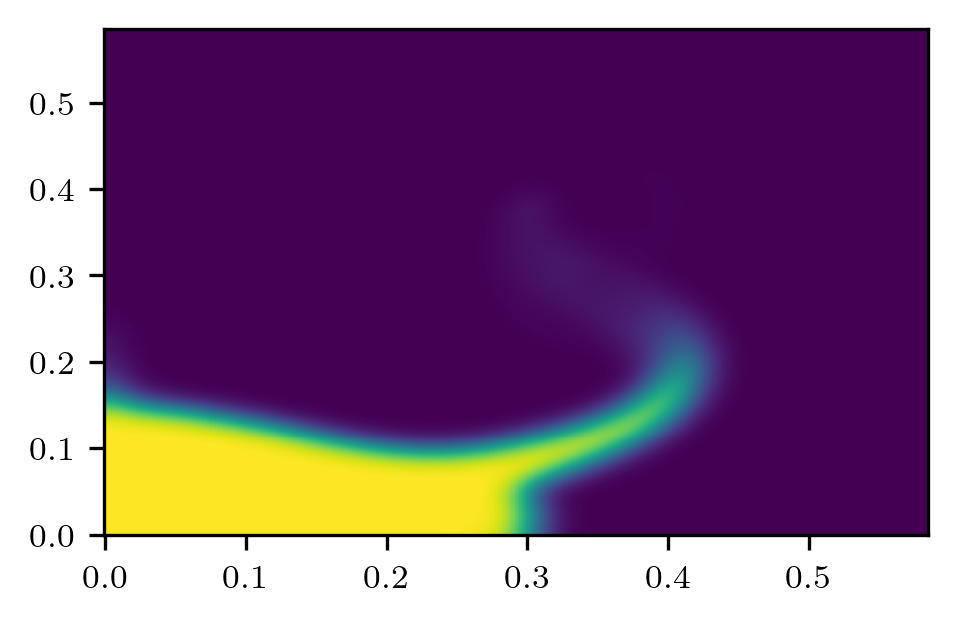

In [12]:
fig,ax = plt.subplots()
ax.pcolormesh(X, Y, np.mean(X_train_grid_s, axis=0).reshape(case["shape"]))
plt.show()
wall_grad = np.mean(X_train_grid_s, axis=0).reshape(case["shape"])[is_wall].copy()

In [13]:
def _richardson_lucy_truncate(sgm, dx):
    """Truncate for Gaussian kernel (shared by CPU and GPU RL)."""
    truncate = 8
    if sgm / dx > 800:
        truncate = 1
    elif sgm / dx > 400:
        truncate = 2
    elif sgm / dx > 200:
        truncate = 3
    elif sgm / dx > 100:
        truncate = 4
    elif sgm / dx > 50:
        truncate = 5
    elif sgm / dx > 25:
        truncate = 5
    return truncate

def richardson_lucy_gpu(
    x,
    im_blur,
    sgm,
    num_iter=50,
    damping=1,
    clip=True,
    mode="wrap",
    monitor_convergence=False,
    clip_min=0,
    clip_max=1,
):
    """GPU Richardson–Lucy deconvolution. Requires CuPy. Same signature as richardson_lucy."""

    if not len(im_blur.shape) == 2:
        warnings.warn("image needs to be 2D")
    if monitor_convergence:
        raise ValueError("monitor_convergence not implemented in GPU version")
    dx = float(x[1] - x[0])
    truncate = _richardson_lucy_truncate(sgm, dx)

    im_deconv = im_blur.copy()
    eps = 1e-7
    sigma_pixels = sgm / dx
    if clip:
        target_mass = cp.sum(im_blur)
    print("renormalizing")
    for k in range(num_iter):
        blurred = gaussian_filter_gpu(im_deconv, sigma=sigma_pixels, truncate=truncate, mode=mode)
        #blurred[cp.abs(blurred) < eps] = eps
        blurred = cp.maximum(blurred, eps)

        relative_blur = im_blur / blurred
        error_estimate = gaussian_filter_gpu(relative_blur, sigma=sigma_pixels, truncate=truncate, mode=mode)
        if damping:
            error_estimate = cp.clip(error_estimate, 1 - damping, 1 + damping)
        im_deconv *= error_estimate
        if clip:
            im_deconv = cp.clip(im_deconv, clip_min, clip_max)
            mass = cp.sum(im_deconv)
            if mass > 0:
                im_deconv *= target_mass / mass
    im_deconv_np = cp.asnumpy(im_deconv)
    return im_deconv_np, False

def clip_redistribute_weighted_gpu(y, target_mass, lo=0.0, hi=1.0, tol=1, max_iter=10):
    """
    Redistribution is weighted by available room:
      - add mass proportional to (hi - u)
      - remove mass proportional to (u - lo)
    """
    u = cp.clip(y, lo, hi)
    for _ in range(max_iter):
        delta = target_mass - cp.sum(u)
        print(delta)
        if cp.abs(delta) < tol:
            return u, True
        active = (u > lo + tol) & (u < hi - tol)
        if not bool(active.any().item()):
            return u, False
        if delta > 0:
            w = cp.where(active, hi - u, 0.0)   # room to go up
        else:
            w = cp.where(active, u - lo, 0.0)   # room to go down
        wsum = cp.sum(w)
        if wsum < tol:
            return u, False
        u = u + delta * (w / wsum)
        u = cp.clip(u, lo, hi)
    success = bool(cp.abs(target_mass - cp.sum(u)).item() < 10 * tol)
    return u, success

def richardson_lucy2_gpu(
    x,
    im_blur,
    sgm,
    num_iter=50,
    damping=1,
    clip=True,
    mode="wrap",
    monitor_convergence=False,
    clip_min=0,
    clip_max=1,
):
    """GPU Richardson–Lucy deconvolution. Requires CuPy. Same signature as richardson_lucy."""

    if not len(im_blur.shape) == 2:
        warnings.warn("image needs to be 2D")
    if monitor_convergence:
        raise ValueError("monitor_convergence not implemented in GPU version")
    dx = float(x[1] - x[0])
    truncate = _richardson_lucy_truncate(sgm, dx)

    im_deconv = im_blur.copy()
    eps = 1e-7
    sigma_pixels = sgm / dx
    target_mass = cp.sum(im_blur)
    #print("v3")
    for k in range(num_iter):
        im_deconv[is_wall] = wall_grad
        blurred = gaussian_filter_gpu(im_deconv, sigma=sigma_pixels, truncate=truncate, mode=mode)
        #blurred[cp.abs(blurred) < eps] = eps
        blurred = cp.maximum(blurred, eps)

        relative_blur = im_blur / blurred
        error_estimate = gaussian_filter_gpu(relative_blur, sigma=sigma_pixels, truncate=truncate, mode=mode)
        error_estimate = cp.maximum(error_estimate, eps)
        #if damping and damping>0:
        #    error_estimate = cp.clip(error_estimate, 1 - damping, 1 + damping)
        # # 1.
        alpha = 1.0
        trial = im_deconv * error_estimate**alpha
        im_deconv = trial
        # im_deconv, ok = clip_redistribute_weighted_gpu(im_deconv, target_mass=target_mass, lo=clip_min, hi=clip_max)
        # im_deconv = project_box_mass_gpu(
        #     trial,
        #     target_mass=target_mass,
        #     lo=clip_min,
        #     hi=clip_max,
        #     mask_fixed=is_wall,
        #     fixed_values=wall_grad,
        # )
        # # 2.
        # proposal = im_deconv * error_estimate
        # im_deconv = im_deconv + (1 - im_deconv) * (proposal - im_deconv)
        # 3.
        #proposal = im_deconv * error_estimate
        #im_deconv = proposal / (1 - im_deconv + proposal)

        #mass = cp.sum(im_deconv)
        #deficit = target_mass - mass
        #if deficit > 0:
        #    capacity = cp.maximum(clip_max - im_deconv, 0)
        #    cap_sum = cp.sum(capacity)
        #    if cap_sum > 0:
        #        im_deconv += deficit * capacity / cap_sum
        # # 4.
        # im_deconv *= error_estimate
        # im_deconv = im_deconv / (1 + im_deconv)
        if clip:
            im_deconv = cp.clip(im_deconv, clip_min, clip_max)
            mass = cp.sum(im_deconv)
            if mass > 0:
                im_deconv *= target_mass / mass
    im_deconv_np = cp.asnumpy(im_deconv)
    return im_deconv_np, False

def get_predictions_gpu(sROM, mu_, sigma, c, num_iter, shape, x, sROM_only=False, monitor_progress_postprocessing=False, monitor_convergence=False, sigmaD="calc_based_on_distance", **kwargs):
    mu_ = np.asarray(mu_)
    X_test_sROM = sROM.predict(mu_).snapshots_matrix
    mu_train = sROM.database.parameters_matrix
    data = X_test_sROM
    if sROM_only:
        return data, None
    mode = kwargs.get("mode", "wrap")

    if monitor_convergence:
        deconvolved = np.ones((*data.shape, num_iter))
    else:
        deconvolved = np.empty_like(data)
    # Transfer all data to GPU once
    data_gpu = cp.asarray(data.astype(np.float32))
    for j in range(len(mu_)):
        if isinstance(sigmaD, np.ndarray):
            sgm_est = sigmaD[j]
        elif sigmaD == "calc_based_on_distance":
            sgm_est = get_sigma(sigma, mu_[j][None, ...], mu_train, c=c)
        else:
            raise ValueError("unknown method for sigmaD.")
        res = richardson_lucy2_gpu(x, data_gpu[j].reshape(shape), sgm_est, num_iter, mode=mode, monitor_convergence=monitor_convergence)[0].reshape(deconvolved[j].shape)
        deconvolved[j] = res
        if monitor_progress_postprocessing:
            print(j, end=", ")
    X_test_sROMs = deconvolved
    return X_test_sROM, X_test_sROMs

In [15]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds

def rmv_wall_inplace(X):
    for j in range(len(X)):
        rmw = X[j].reshape(gridded_shape)
        rmw[is_wall] = wall_grad
        X[j] = rmw.ravel()
    return


X_train_grid_gpu = cp.asarray(X_train_grid.reshape(-1, *gridded_shape).astype(np.float32))
m0 = cp.sum(X_train_grid_gpu, axis=(1,2), keepdims=True)
rmv_wall_inplace(X_test_grid)

    
def target_function(case):           
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    sD = case["sigmaD"][0]
    print(case["sigma"],  case["c"], sD, case["num_iter"], end=" ")
    #truncate = case["truncate"]
    #for j in range(len(X_train_grid)):
    #    ss2D = X_train_grid[j].reshape(case["shape"])
    #    X_train_grid_s[j] = gaussian_filter(ss2D, sigma=sgm, truncate=10, mode='reflect').ravel()
    out = gaussian_filter_gpu(X_train_grid_gpu, sigma=(0, sgm, sgm), mode=mode)
    m1 = cp.sum(out, axis=(1,2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_grid_s = cp.asnumpy(out).reshape(len(X_train_grid), -1)
    

    my_ROM = train_ROM_rw(mu_train, X_train_grid)
    my_sROM = train_ROM_rw(mu_train, X_train_grid_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions_gpu(my_sROM, mu_test, **case)

    rmv_wall_inplace(X_test_ROM)
    rmv_wall_inplace(X_test_sROM)
    rmv_wall_inplace(X_test_sROMs)

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_test_grid, X_test_ROM, X_test_sROM, X_test_sROMs, norm=L2_error_rw, scaler=None
    )
    print(mean_ROM, mean_sROM, mean_sROMs, improvement)
    return mean_ROM, mean_sROM, mean_sROMs



def optimize_hyperparameters(case):
    sigma_opt = 0.013

    def target(params):
        case["sigma"], case["c"], case["num_iter"] = params[0], False, int(params[2])
        case["sigmaD"][:] = params[1]
        return target_function(case)[2]
    #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 2, 50])
    bounds = Bounds([0.001, 0.001, 1], [5 * sigma_opt, 5 * sigma_opt, 200])
    res = direct(target, bounds, eps=1e-2, len_tol=0.01)  # max side length_abs=[0.006, 0.25]
    print(
        "optimization result for sigma:",
        res["x"][0],
        "bounds",
        0.001,
        5 * sigma_opt,
        "guess:",
        sigma_opt,
    )
    print("optimization result for c:", res["x"][1], "bounds", 0, 2)
    print(res.message)
    # TODO: check if bounds were OK
    return res["x"]

case = {
    "sigma": 0.013,
    "c": None,
    "num_iter": 10,
    "shape": gridded_shape,
    "x": x,  # for truncation of kernel and calculation of sgm
    "dx": x[1]-x[0],  # for truncation of kernel and calculation of sgm
    "mode": 'reflect',
    "sigmaD": np.zeros((len(mu_test),))  # sigma_D given for each n_test
        }


In [16]:
parameters = optimize_hyperparameters(case)

0.033 False 0.033 100 0.017491291048286013 0.1260994124946983 0.05453558084515921 211.7870527373289
0.05433333333333333 False 0.033 100 0.017491291048286013 0.1549120263562339 0.1418281181170103 710.8499122533791
0.011666666666666669 False 0.033 100 0.017491291048286013 0.06917596716095561 0.11225732213624798 541.7898017153409
0.033 False 0.05433333333333333 100 0.017491291048286013 0.1260994124946983 0.13130763868561135 650.7029545339268
0.033 False 0.011666666666666669 100 0.017491291048286013 0.1260994124946983 0.12320919992466169 604.4031202987446
0.033 False 0.033 166 0.017491291048286013 0.1260994124946983 0.04843479903155022 176.9080847025091
0.033 False 0.033 34 0.017491291048286013 0.1260994124946983 0.0691697364016733 295.4524352189046
0.05433333333333333 False 0.033 166 0.017491291048286013 0.1549120263562339 0.14185059627949595 710.978422850016
0.011666666666666669 False 0.033 166 0.017491291048286013 0.06917596716095561 0.11584347070952768 562.2922824263409
0.033 False 0.0

In [17]:
def optimize_hyperparameters_3d(case, method="lbfgsb"):
    """
    Optimize (sigma, sigmaD, num_iter) to maximize improvement.
    method: "lbfgsb" (smooth, few evals) or "direct" (robust, more evals).
    Use this instead of DIRECT when the improvement surface is smooth.
    """
    sigma_opt = 0.013
    if "sigmaD" not in case or case["sigmaD"] is None:
        case["sigmaD"] = np.zeros((case["n_test"],))

    def target(params):
        case["sigma"], case["c"], case["num_iter"] = params[0], False, int(round(params[2]))
        case["sigmaD"][:] = params[1]
        return target_function(case)[2]

    bounds = ([0.001, 0.001, 1], [5 * sigma_opt, 5 * sigma_opt, 200])

    # Multi-start to reduce risk of bad local minimum
    starts = [
        np.array([0.0045, 0.0045, 14]),
    ]
    best_fun = np.inf
    best_x = None
    for x0 in starts:
        res = minimize(
            target,
            x0,
            method="L-BFGS-B",
           # method="SLSQP",
            bounds=list(zip(bounds[0], bounds[1])),
            options={"maxfun": 80, "ftol": 1e-4, "eps": np.array([0.00025, 0.00025, 3])},
        )
        print(res.x, res.fun)
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x
    x_best = best_x
    print(
        "L-BFGS-B result: sigma=%.5f sigmaD=%.5f num_iter=%d improvement=%.2f"
        % (x_best[0], x_best[1], int(round(x_best[2])), -best_fun)
    )
    return x_best
x_opt = optimize_hyperparameters_3d(case, method="lbfgsb")

0.0045 False 0.0045 14 0.017491291048286013 0.03296039445640057 0.01835877929418645 4.959543829587375
0.00475 False 0.0045 14 0.017491291048286013 0.034465217669763994 0.019090864053538773 9.144968206389223
0.0045 False 0.00475 14 0.017491291048286013 0.03296039445640057 0.018752044419150658 7.207892015427802
0.0045 False 0.0045 17 0.017491291048286013 0.03296039445640057 0.0183361982732467 4.830445177707347
0.001 False 0.001 14 0.017491291048286013 0.017751355887868463 0.01757442210267604 0.4752711172693722
0.00125 False 0.001 14 0.017491291048286013 0.018036218005372615 0.01764213916906402 0.862418447909775
0.001 False 0.00125 14 0.017491291048286013 0.017751355887868463 0.01781122582916373 1.829109011990667
0.001 False 0.001 17 0.017491291048286013 0.017751355887868463 0.017578307450130653 0.49748415714097405
[1.00000000e-03 1.00000000e-03 1.40000075e+01] 0.01757442210267604
L-BFGS-B result: sigma=0.00100 sigmaD=0.00100 num_iter=14 improvement=-0.02


In [18]:
parameters = [0.011631372 , 0.011863069, 75]

In [19]:
case["sigma"], case["c"], case["num_iter"] = parameters[0], False, int(parameters[2])
case["sigmaD"][:] = parameters[1]
sgm = case["sigma"] / case["dx"]
mode = case["mode"]
sD = case["sigmaD"][0]
if True:
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    sD = case["sigmaD"][0]
    print(case["sigma"],  case["c"], sD, case["num_iter"], end=" ")
    #for j in range(len(X_train_grid)):
    #    ss2D = X_train_grid[j].reshape(case["shape"])
    #    X_train_grid_s[j] = gaussian_filter(ss2D, sigma=sgm, truncate=10, mode='reflect').ravel()
    out = gaussian_filter_gpu(X_train_grid_gpu, sigma=(0, sgm, sgm), mode=mode)
    m1 = cp.sum(out, axis=(1,2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_grid_s = cp.asnumpy(out).reshape(len(X_train_grid), -1)


    my_ROM = train_ROM_rw(mu_train, X_train_grid)
    my_sROM = train_ROM_rw(mu_train, X_train_grid_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions_gpu(my_sROM, mu_test, **case)

    rmv_wall_inplace(X_test_ROM)
    rmv_wall_inplace(X_test_sROM)
    rmv_wall_inplace(X_test_sROMs)

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_test_grid, X_test_ROM, X_test_sROM, X_test_sROMs, norm=L2_error_rw, scaler=None
    )
    print(mean_ROM, mean_sROM, mean_sROMs, improvement)
    
    e_ROM = L2_error_rw(X_test_ROM, X_test_grid)
    e_sROMs = L2_error_rw(X_test_sROMs, X_test_grid)
    imprmt_perss = 100 * e_sROMs / e_ROM - 100
    print(imprmt_perss)

0.011631372 False 0.011863069 75 0.017491291048286013 0.06903153309816404 0.02122051445257393 21.320458244009075
[ 43.64881415  12.47567247  -2.14037608  -9.96045381 145.24511702
  31.31617803  33.70505789  16.90131449  37.31136814  60.86287548
  -9.52891129  15.24342859  36.10498406  13.91501006  34.14425443
   0.32843055  70.77630583  83.42312367  16.29170449   9.65947877
   7.34205436]


In [20]:
mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
    X_test_grid, X_test_ROM, X_test_sROM, X_test_sROMs, norm=L2_error_rw, scaler=None
)
print(X_test_grid.shape, X_test_ROM.shape, X_test_sROM.shape, X_test_sROMs.shape)
print(mean_ROM, mean_sROM, mean_sROMs, improvement)

(21, 262144) (21, 262144) (21, 262144) (21, 262144)
0.017491291048286013 0.06903153309816404 0.02122051445257393 21.320458244009075


0 0.0 -5.648693318649478e-15 -2.2705479668595676e-07 0.0
0 1.0 1.0000000000000706 1.0000001846727924 1.0029600858688354
0 33078.33594337566 33077.91312707279 33041.47938476375 33042.86035255256


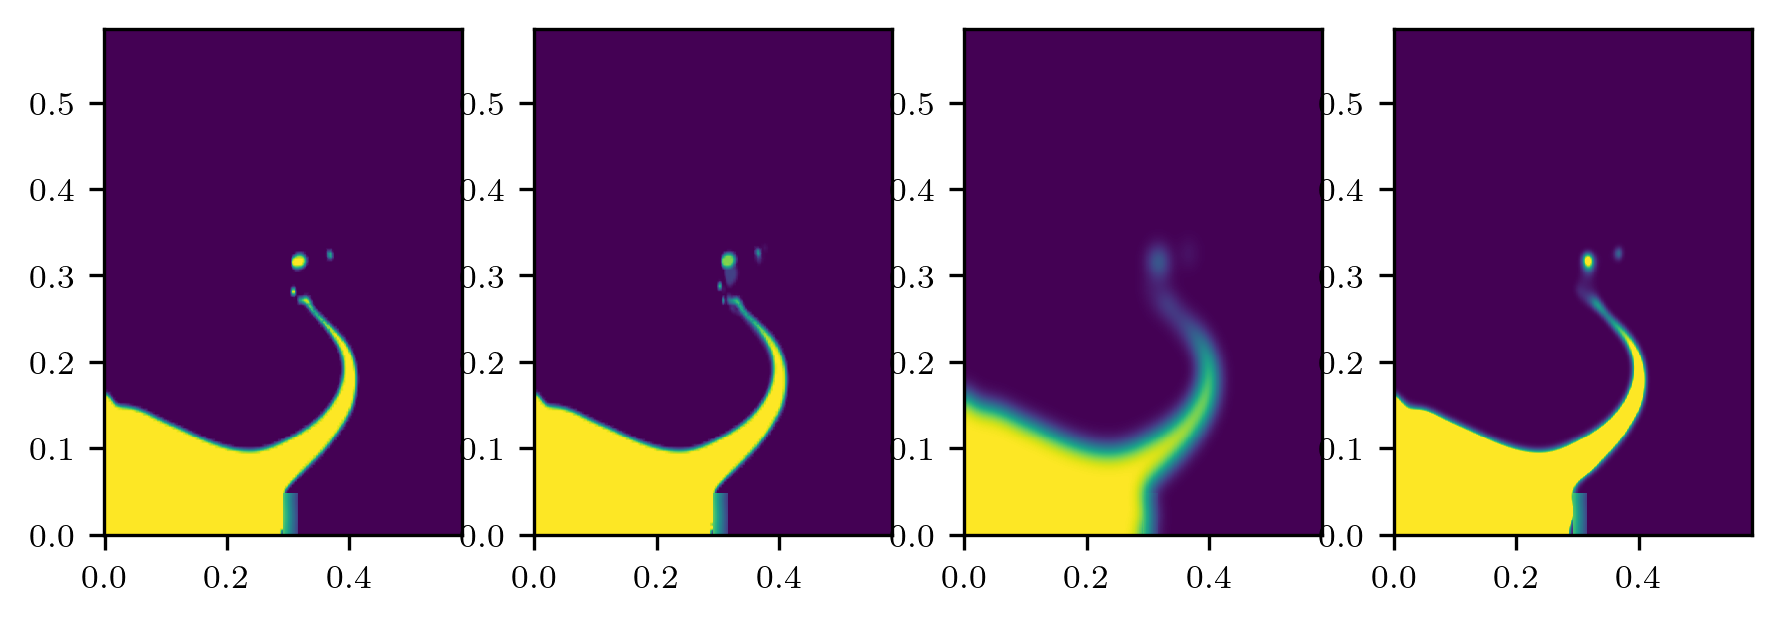

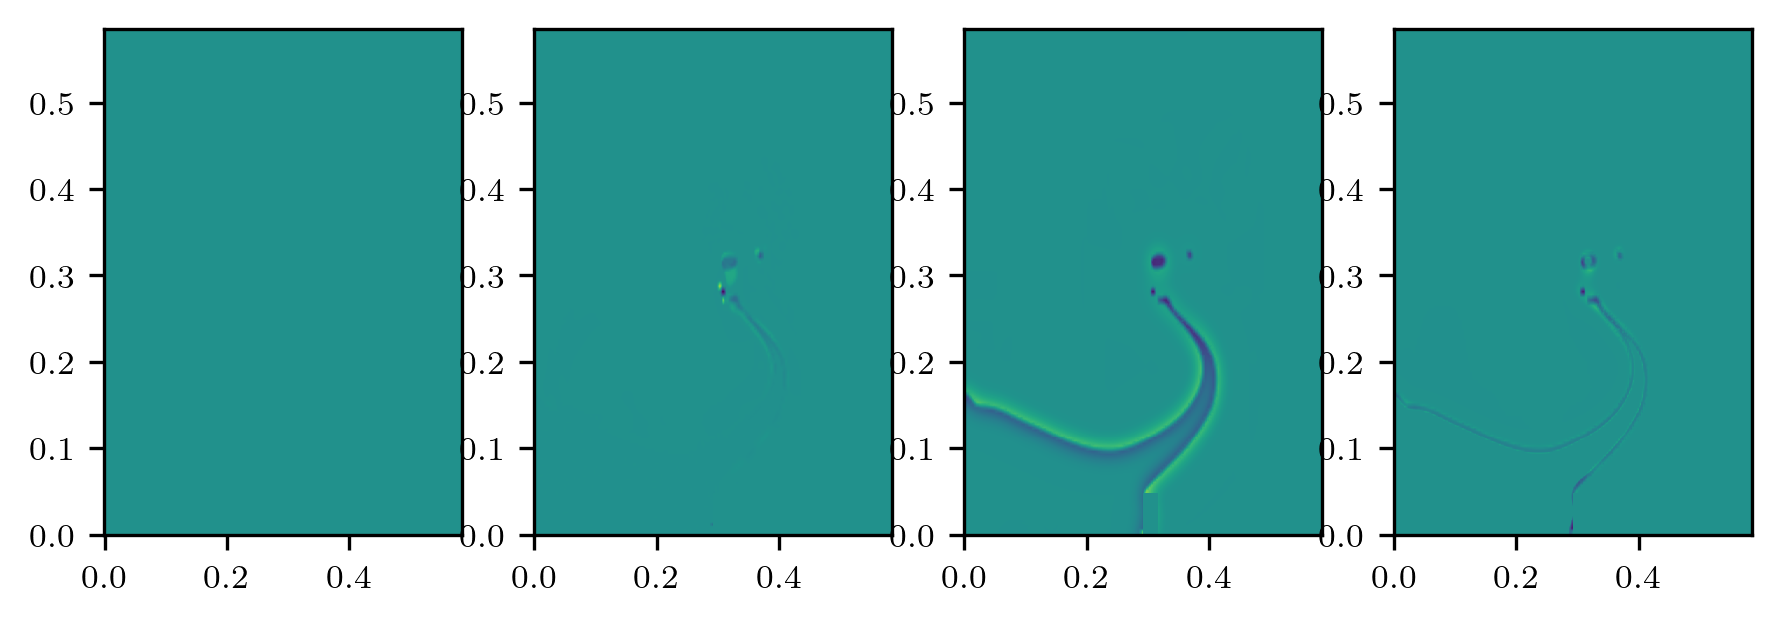

1 0.0 -2.418204525511669e-15 -1.634406063940534e-07 0.0
1 1.0 1.0000000000001186 0.9999994074076715 1.0028811693191528
1 33073.342560377954 33069.49017656318 33041.951783388315 33052.733276686704


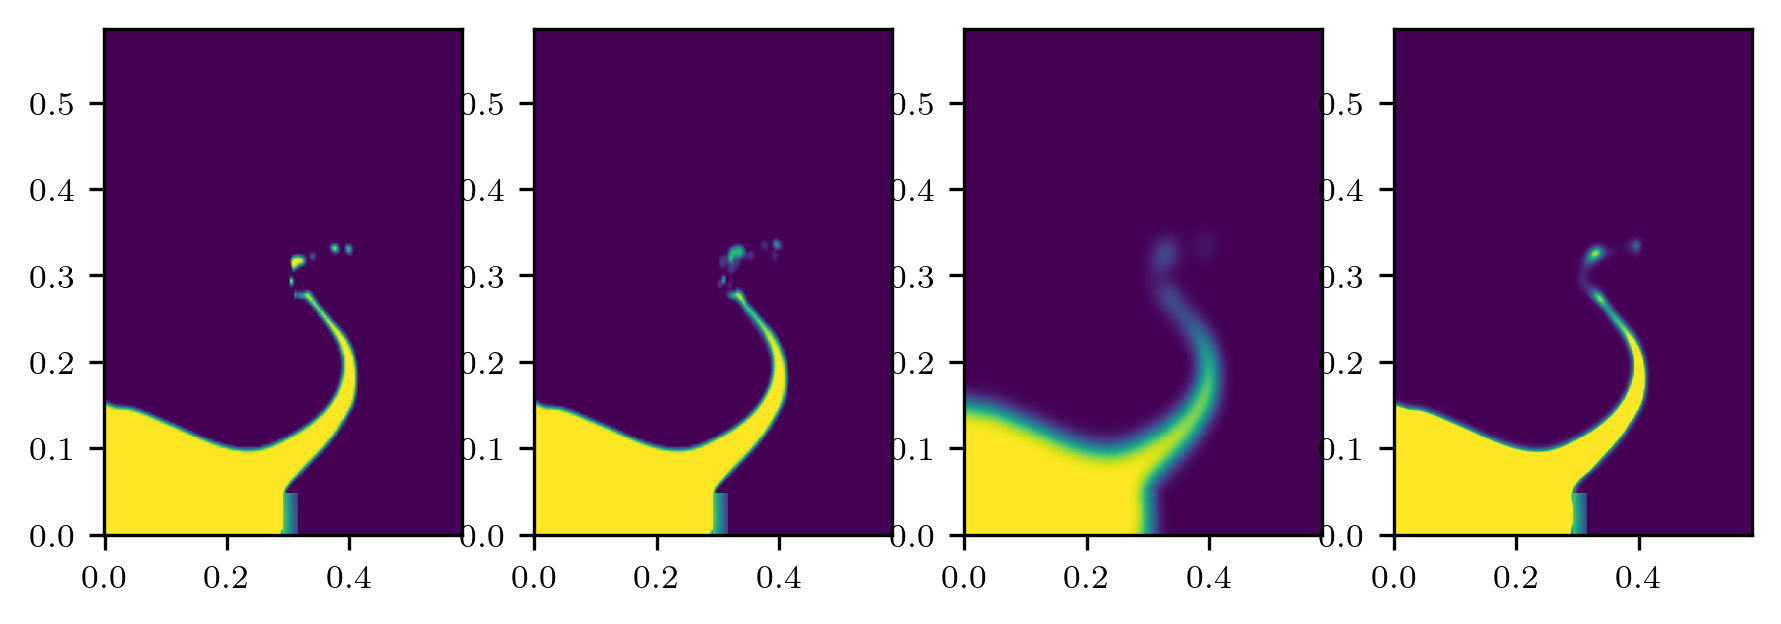

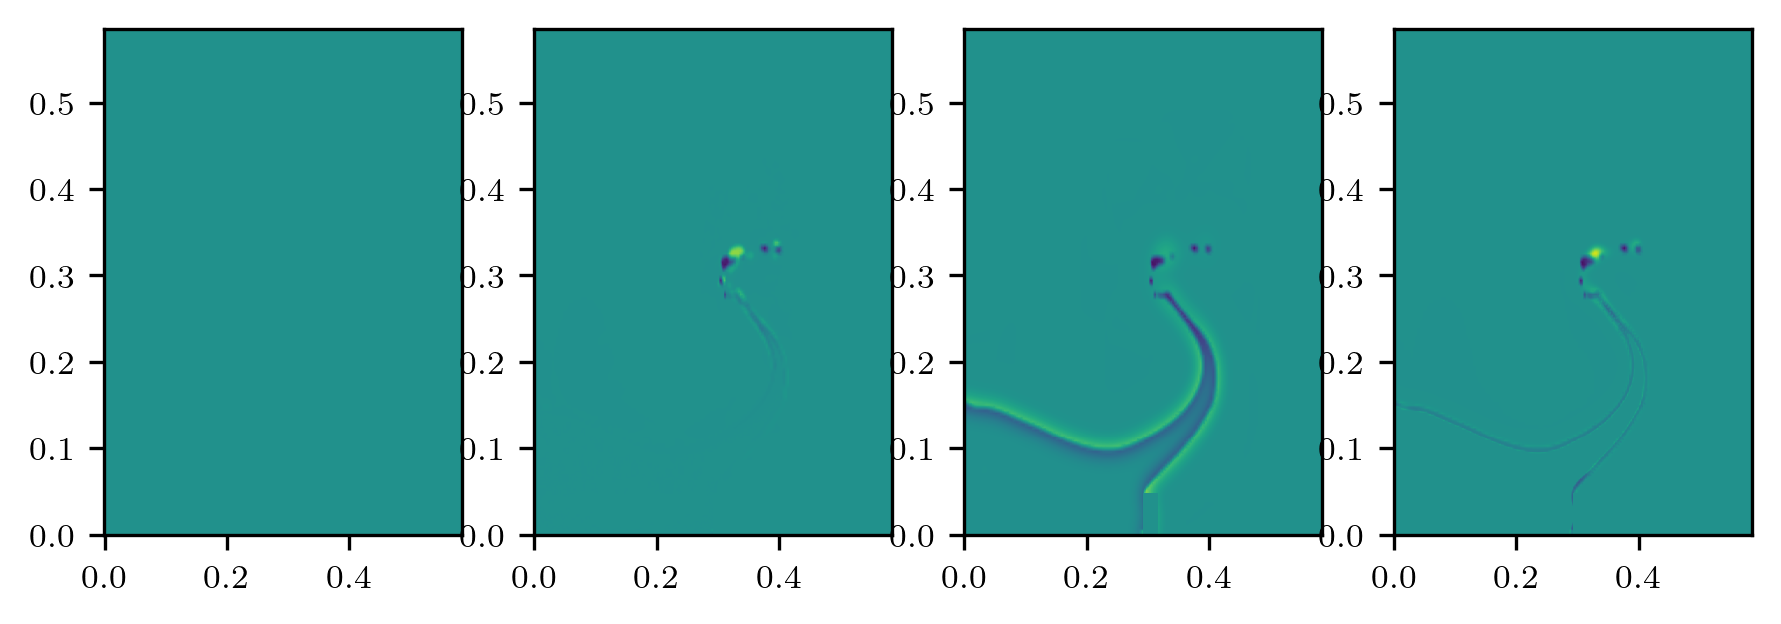

2 0.0 -2.5954932647564988e-14 -1.6576699144200675e-07 0.0
2 1.0 1.0000000000001745 1.0000000574355377 1.002763032913208
2 33114.76100249427 33113.33237234776 33077.2249224954 33090.26064414792


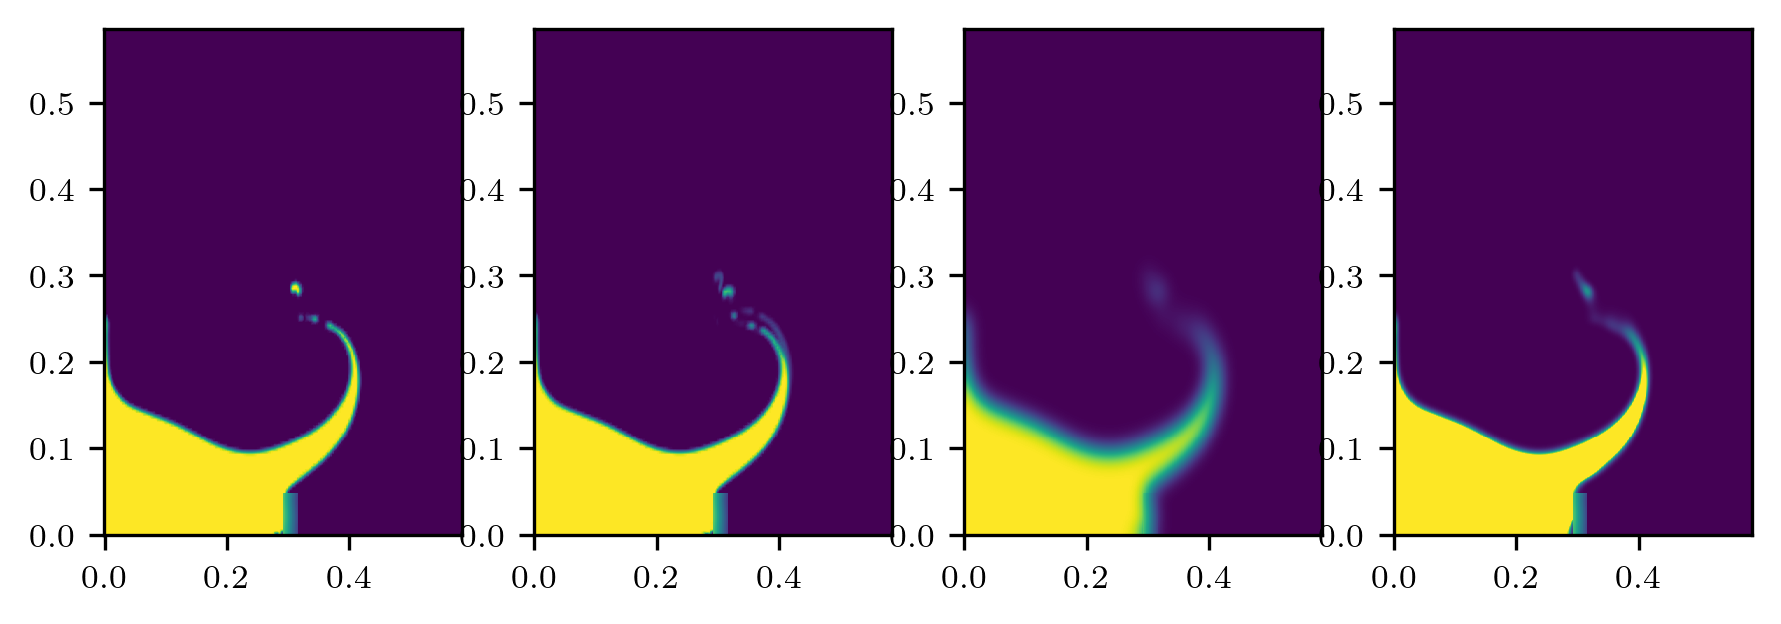

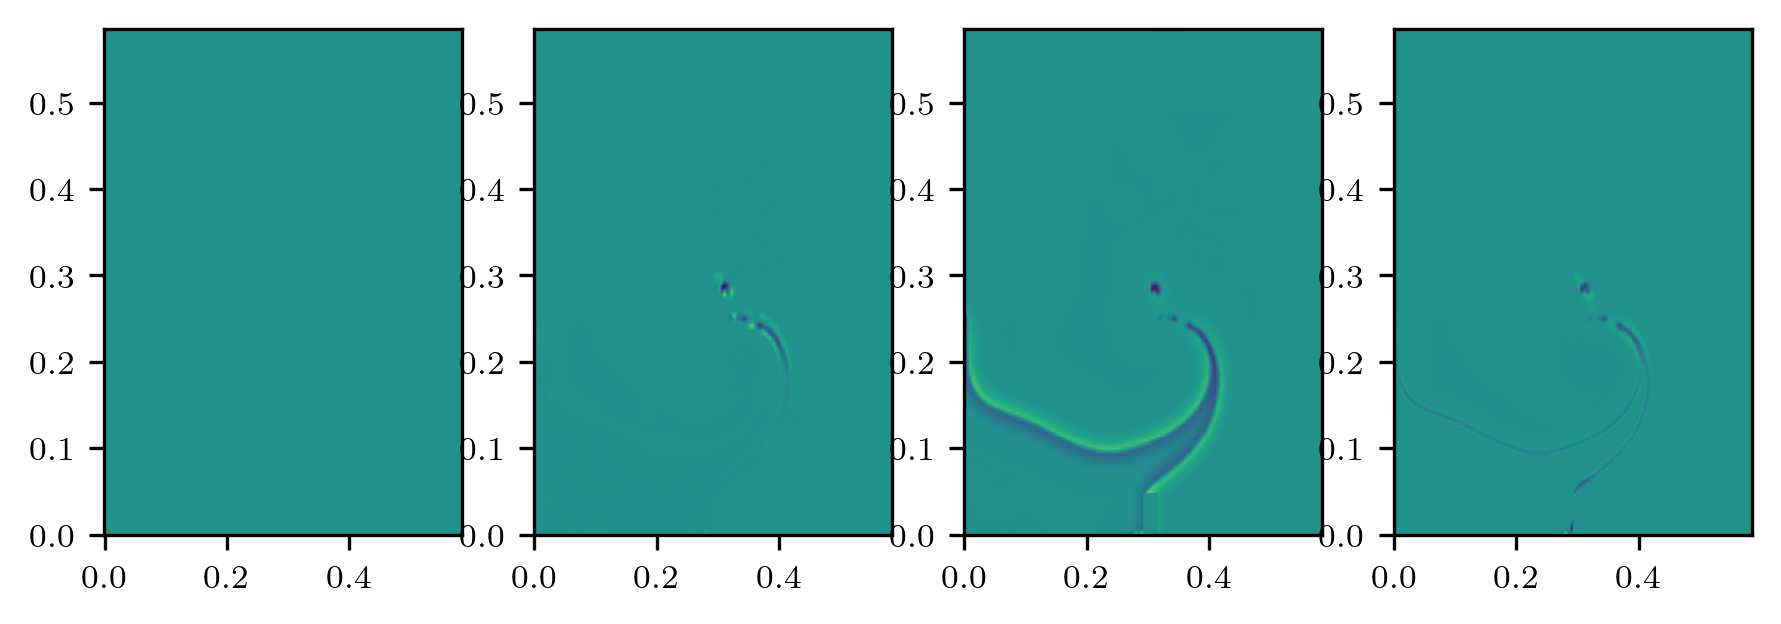

3 0.0 -2.66869859544272e-14 -1.392858802353982e-07 0.0
3 1.0 1.000000000000174 0.9999997607495625 1.002711534500122
3 33116.20129334933 33112.27170793795 33074.31603988697 33085.52005279696


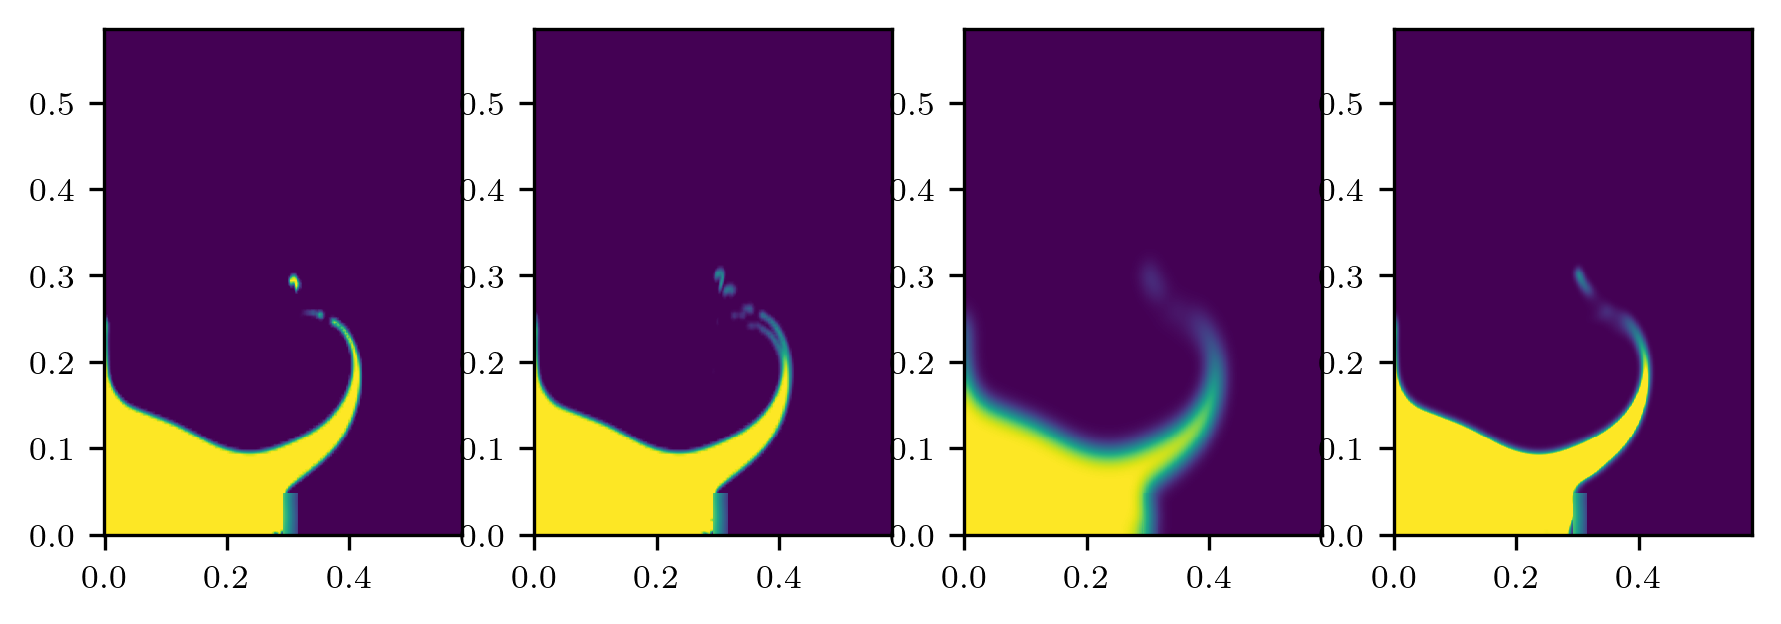

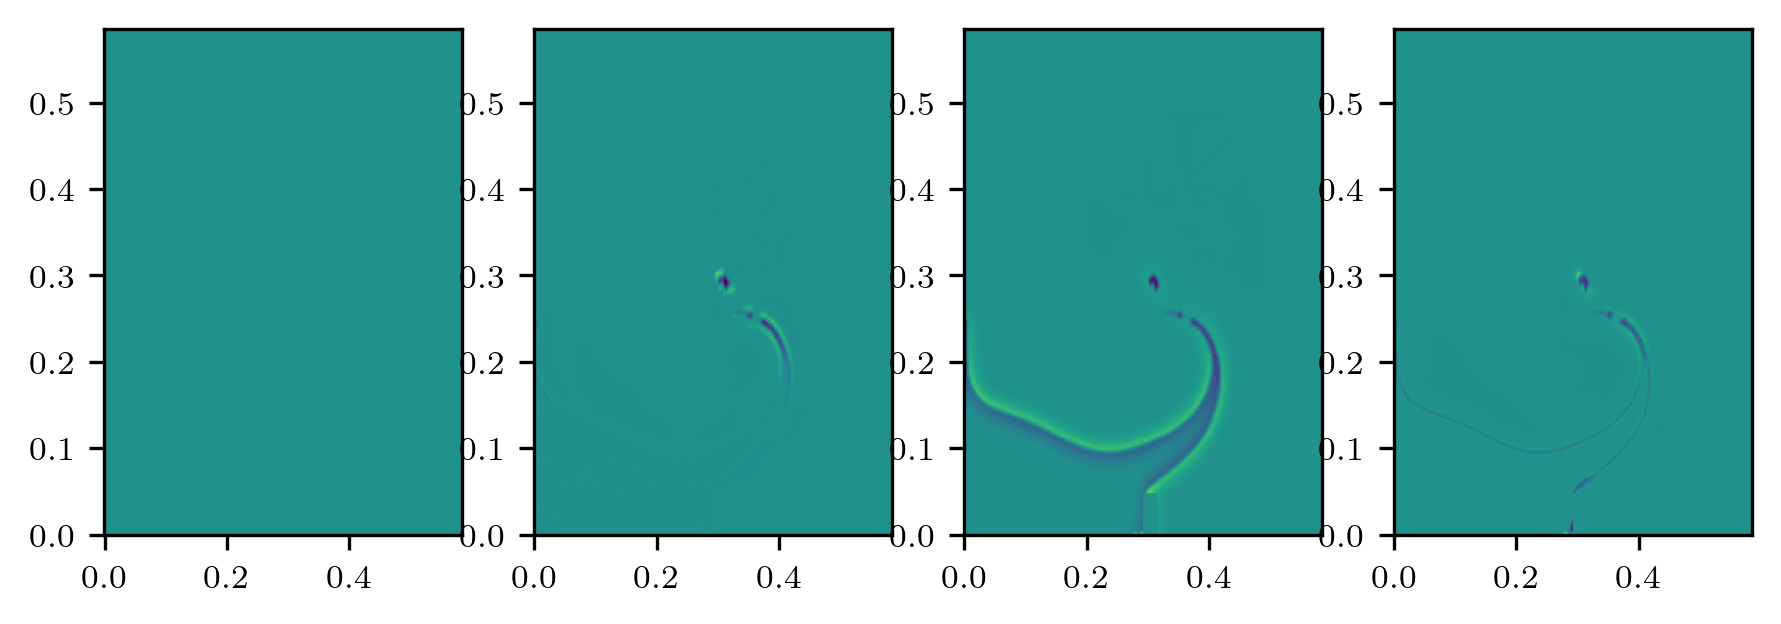

4 0.0 -1.5317608292875207e-14 -2.8973515001602733e-07 0.0
4 1.0 1.000000000000252 0.9999996907034236 1.0029903650283813
4 33110.25796771249 33109.70251234004 33083.85748984095 33104.45668981477


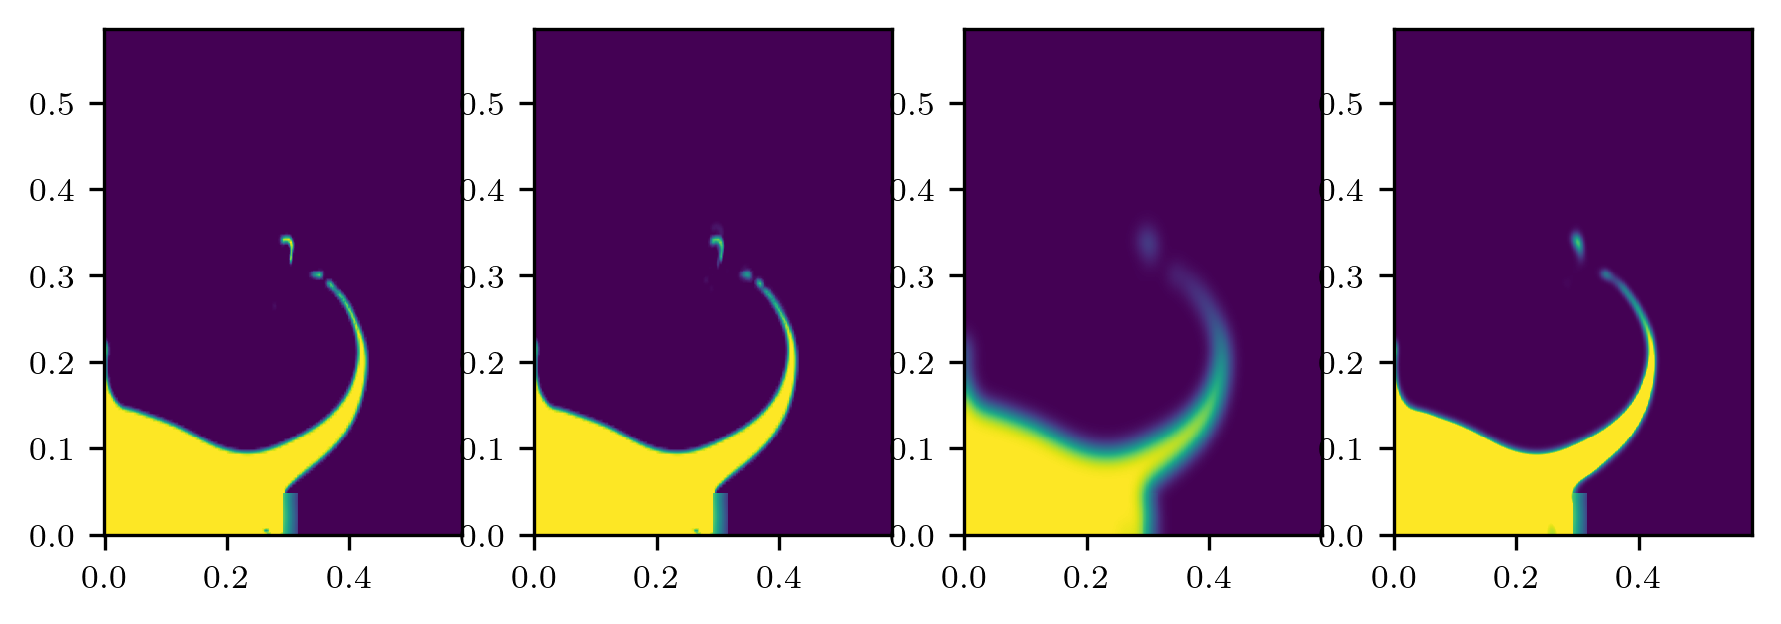

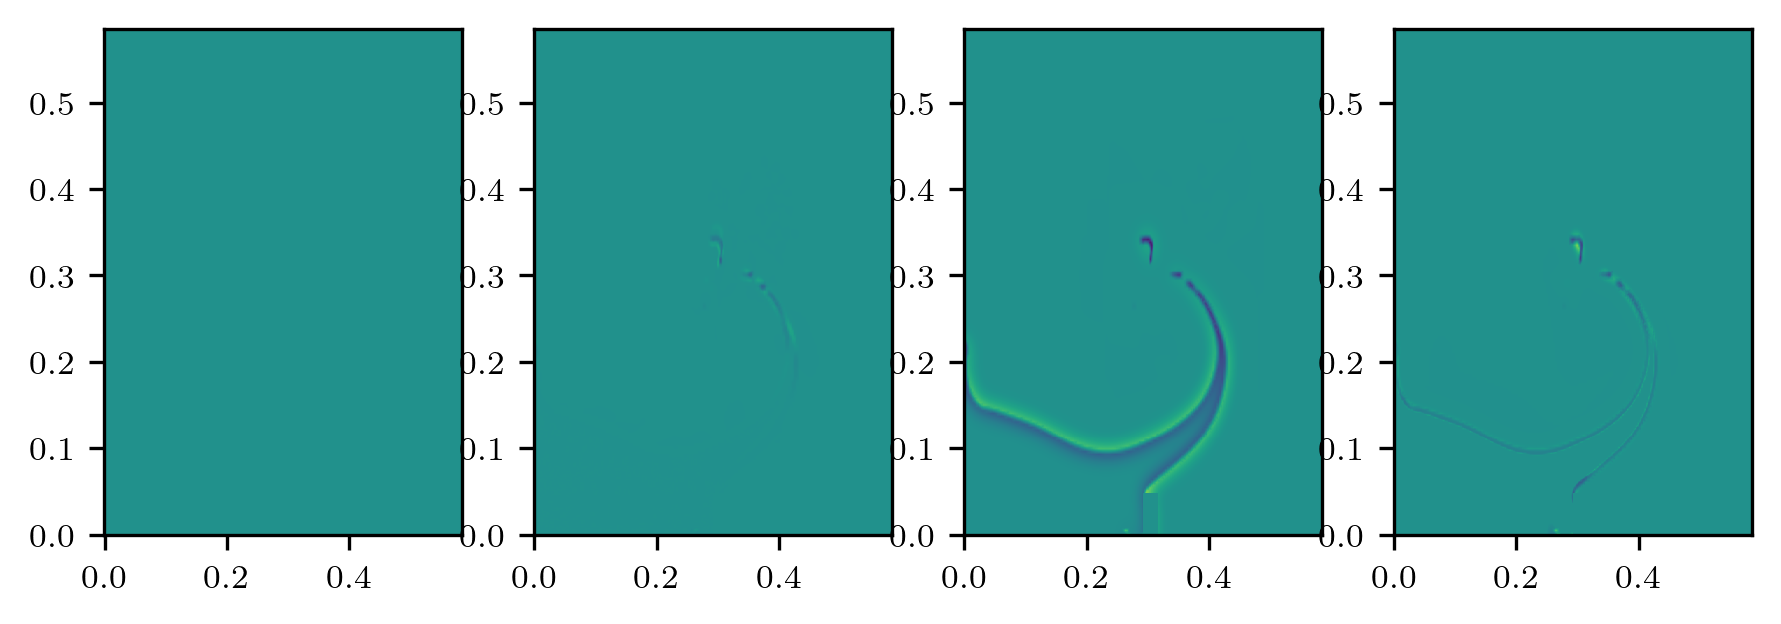

5 0.0 -2.8209639485465843e-14 -1.7729014156715262e-07 0.0
5 1.0 1.0000000000001055 0.999999665941207 1.0029022693634033
5 33107.3379784167 33105.68727034789 33078.77941381726 33099.570631373135


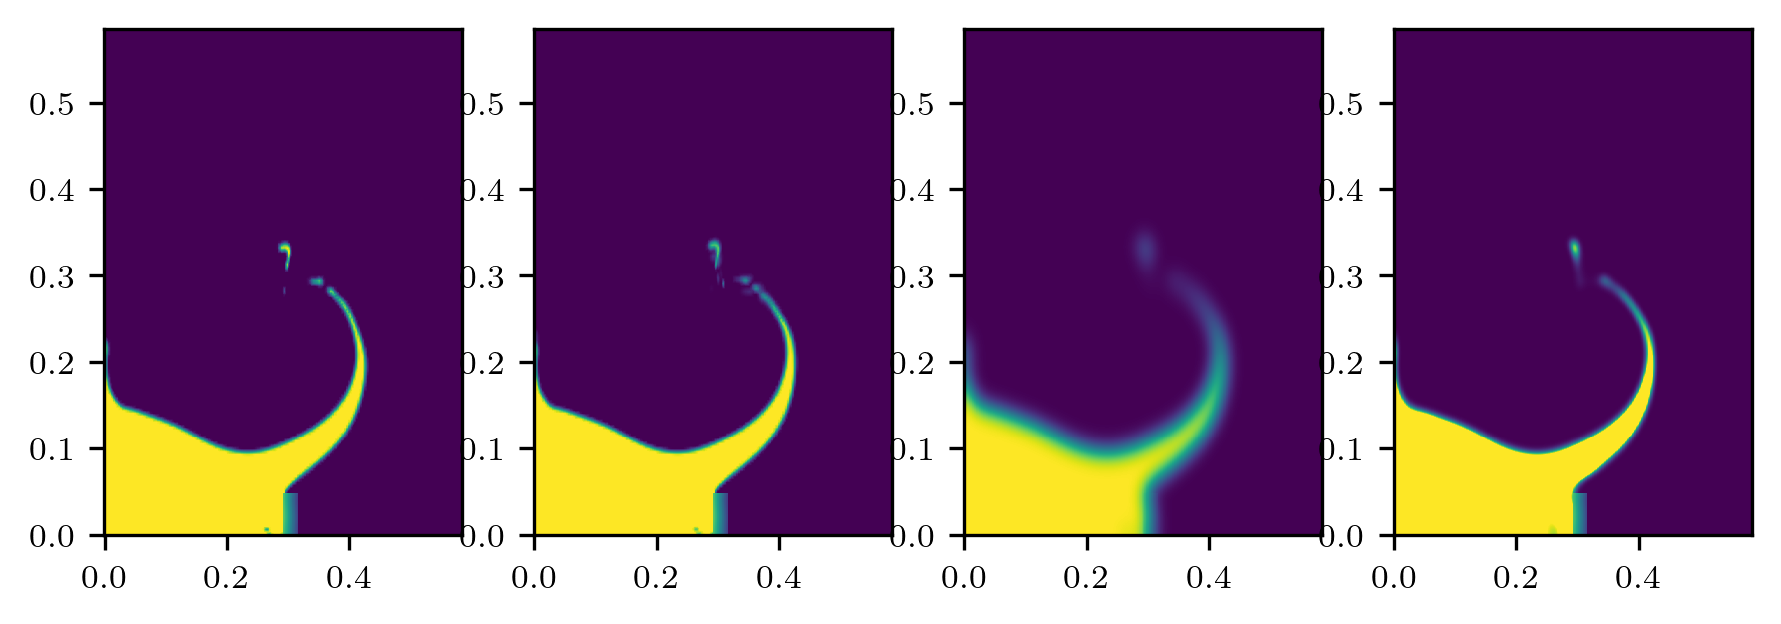

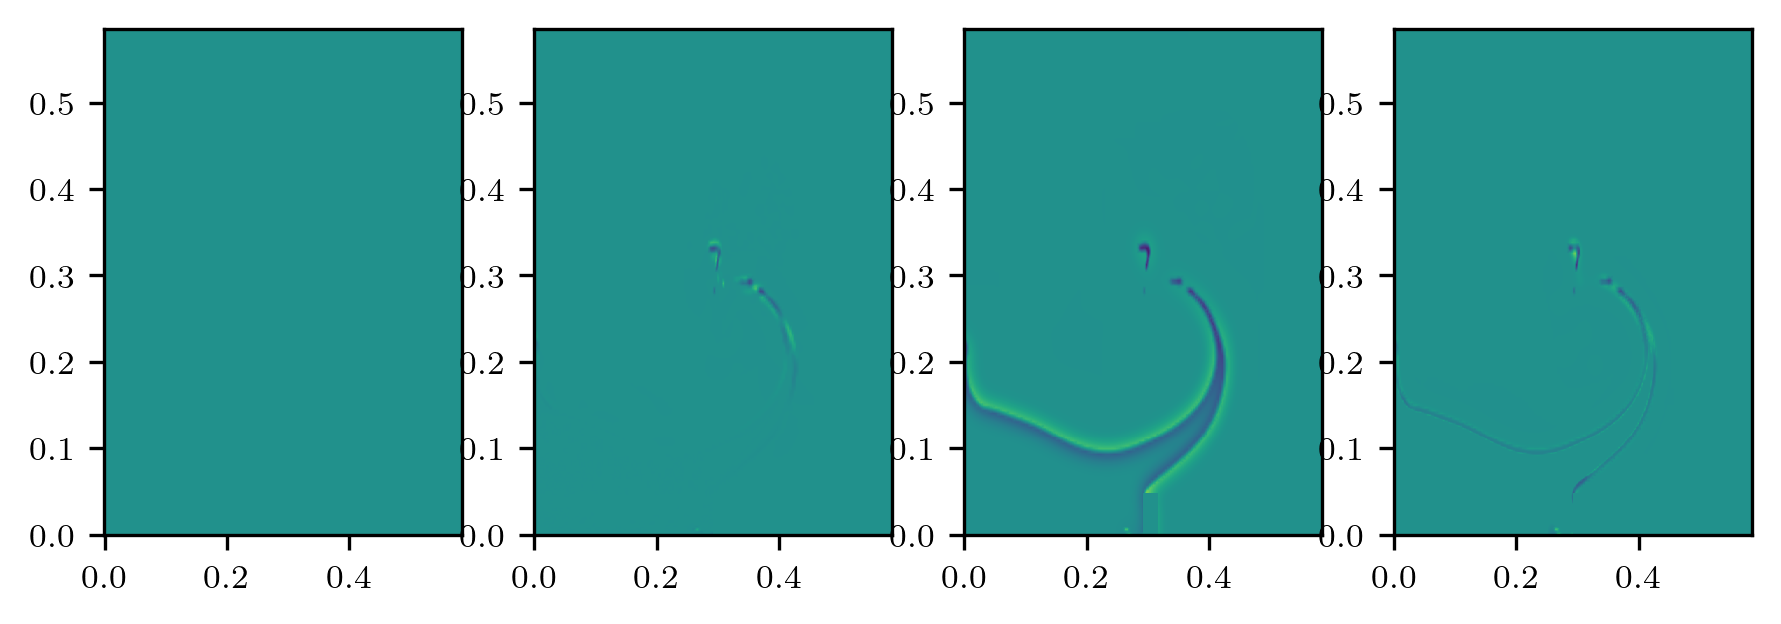

6 0.0 -2.1524448889920222e-14 -2.2067992059394232e-07 0.0
6 1.0 1.0000000000001565 1.0000003283794932 1.0028226375579834
6 33107.78607145665 33101.60205118117 33068.5286003112 33083.35883094106


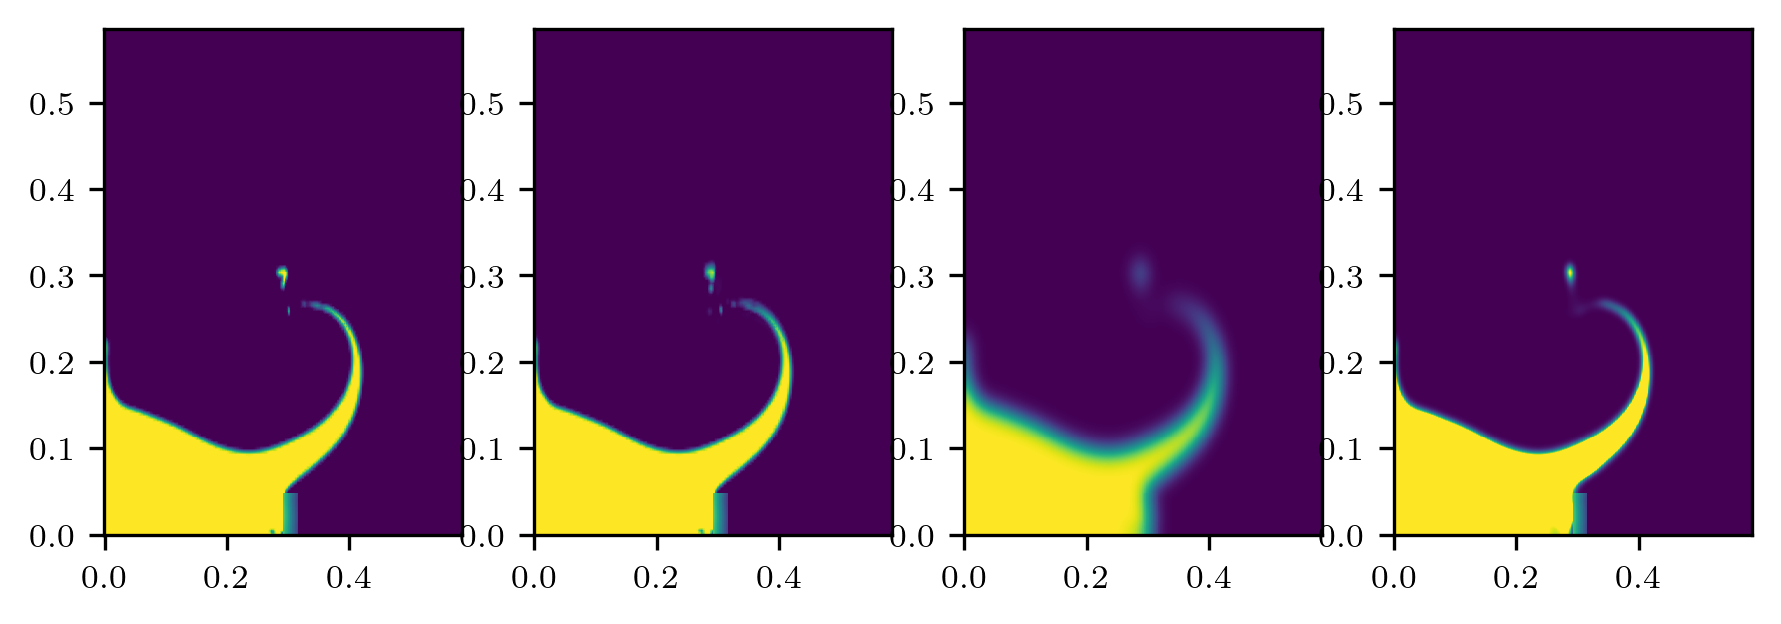

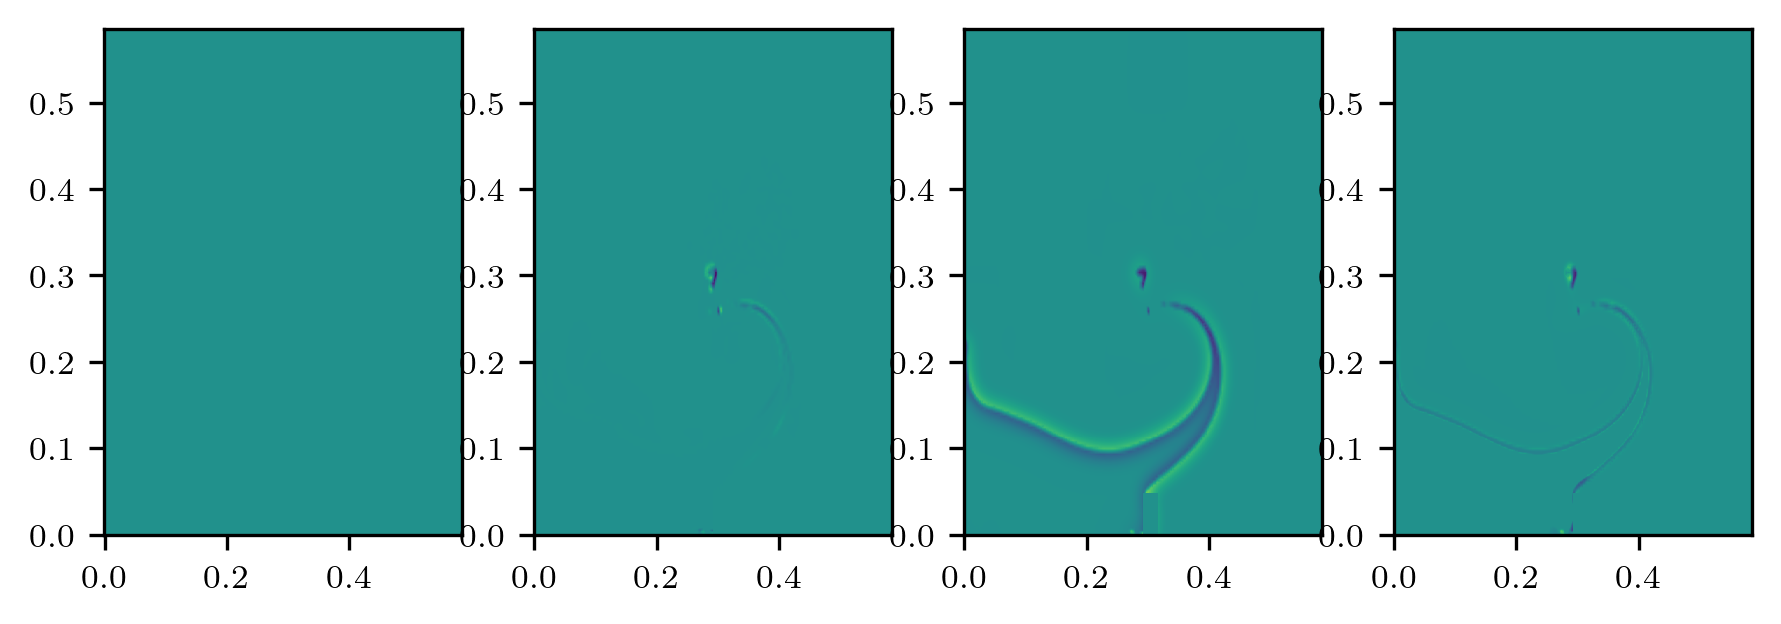

7 0.0 -1.807581861967833e-15 -7.617101107951457e-08 0.0
7 1.0 1.0000000000003488 1.000000314234744 1.002898097038269
7 33072.619130746105 33073.0857431215 33048.89272952735 33062.55853198707


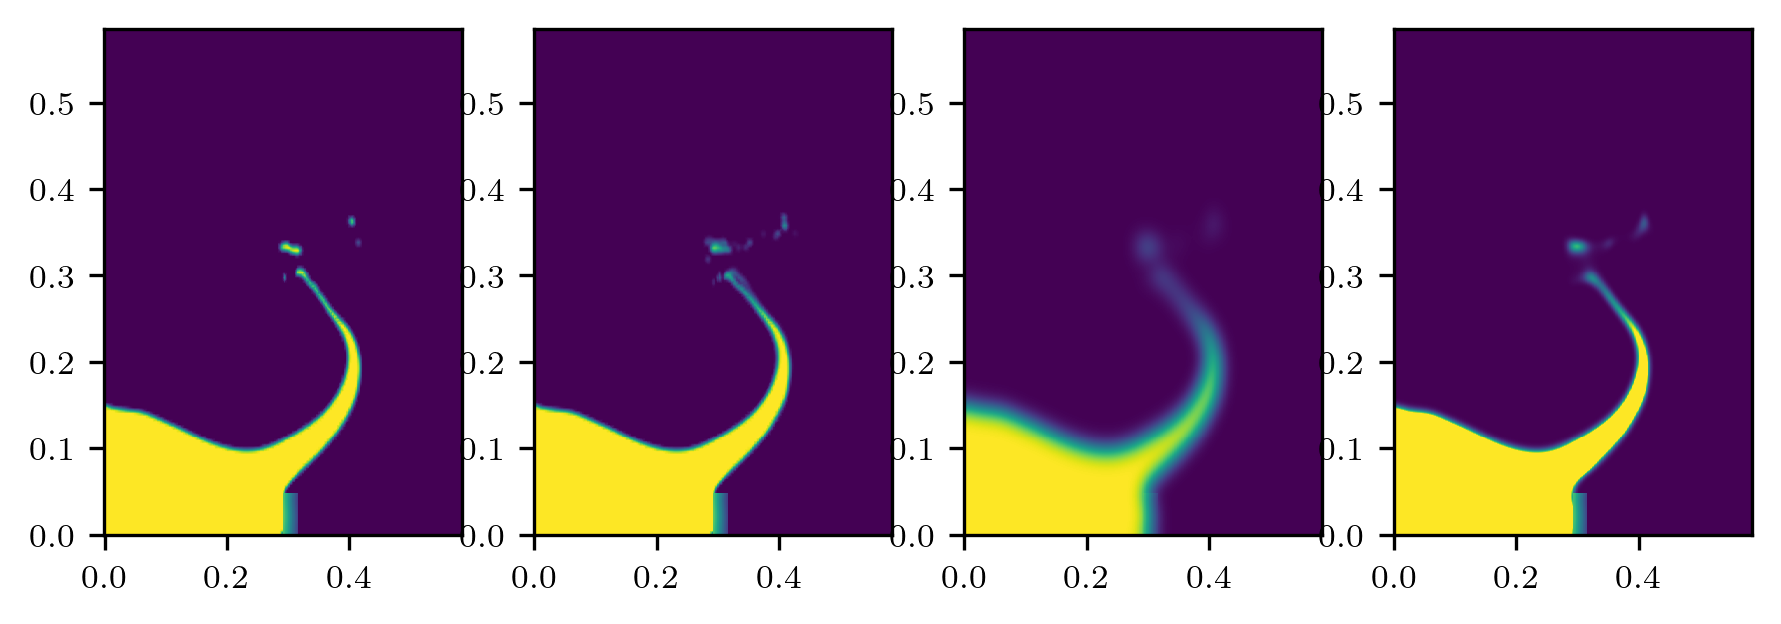

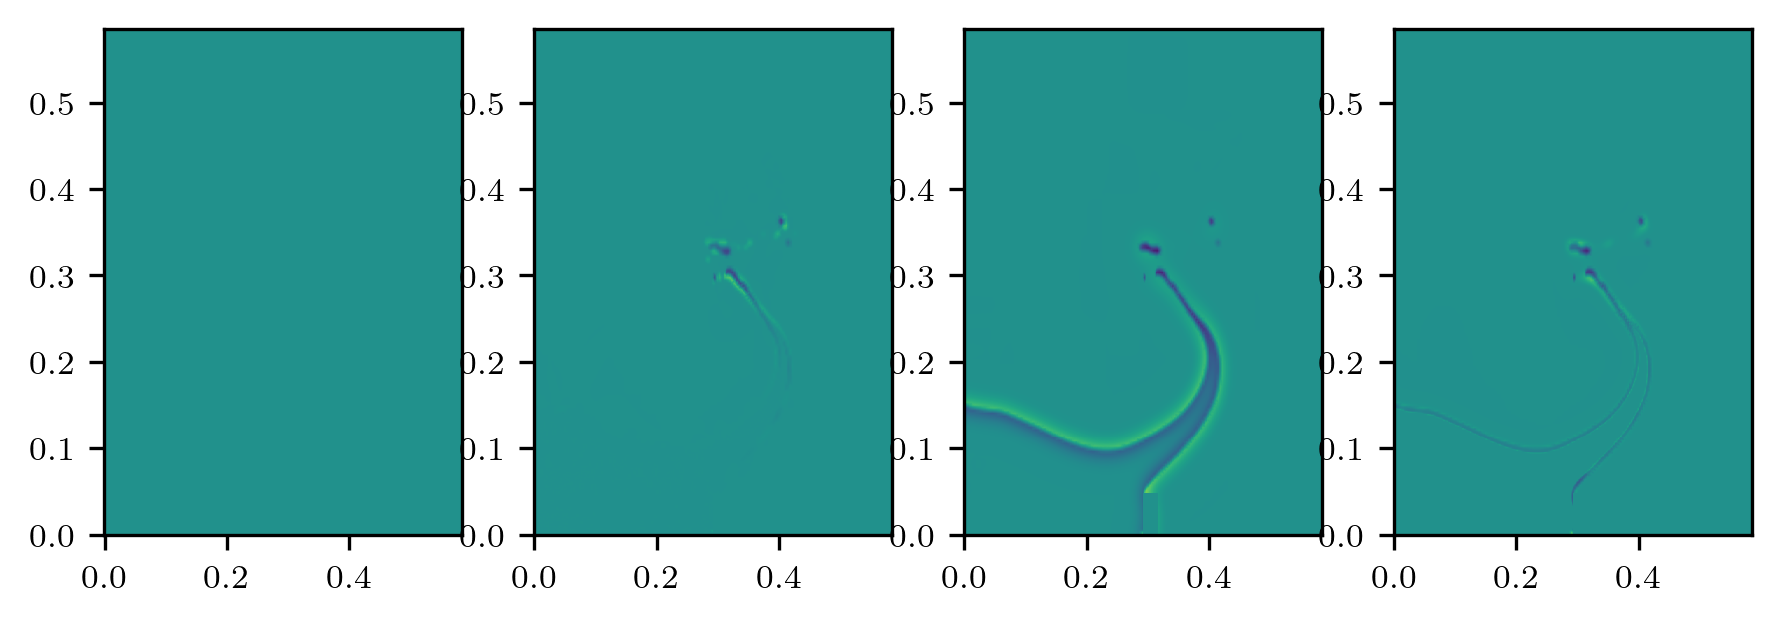

8 0.0 -1.8153881176097286e-14 -2.2258366313959434e-07 0.0
8 1.0 1.0000000000002103 0.9999997238611472 1.002822995185852
8 33100.95337408482 33100.3303745327 33070.75357795039 33088.89324392387


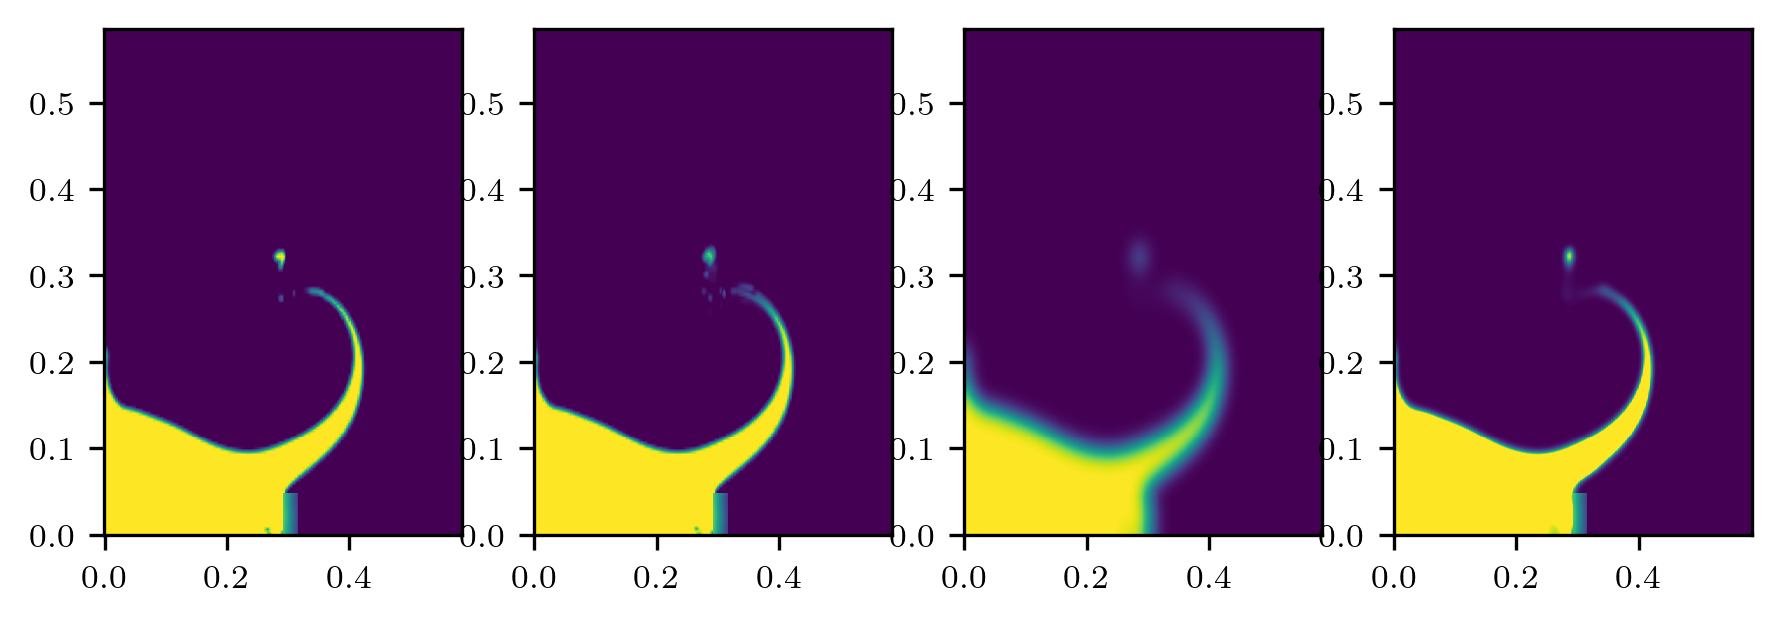

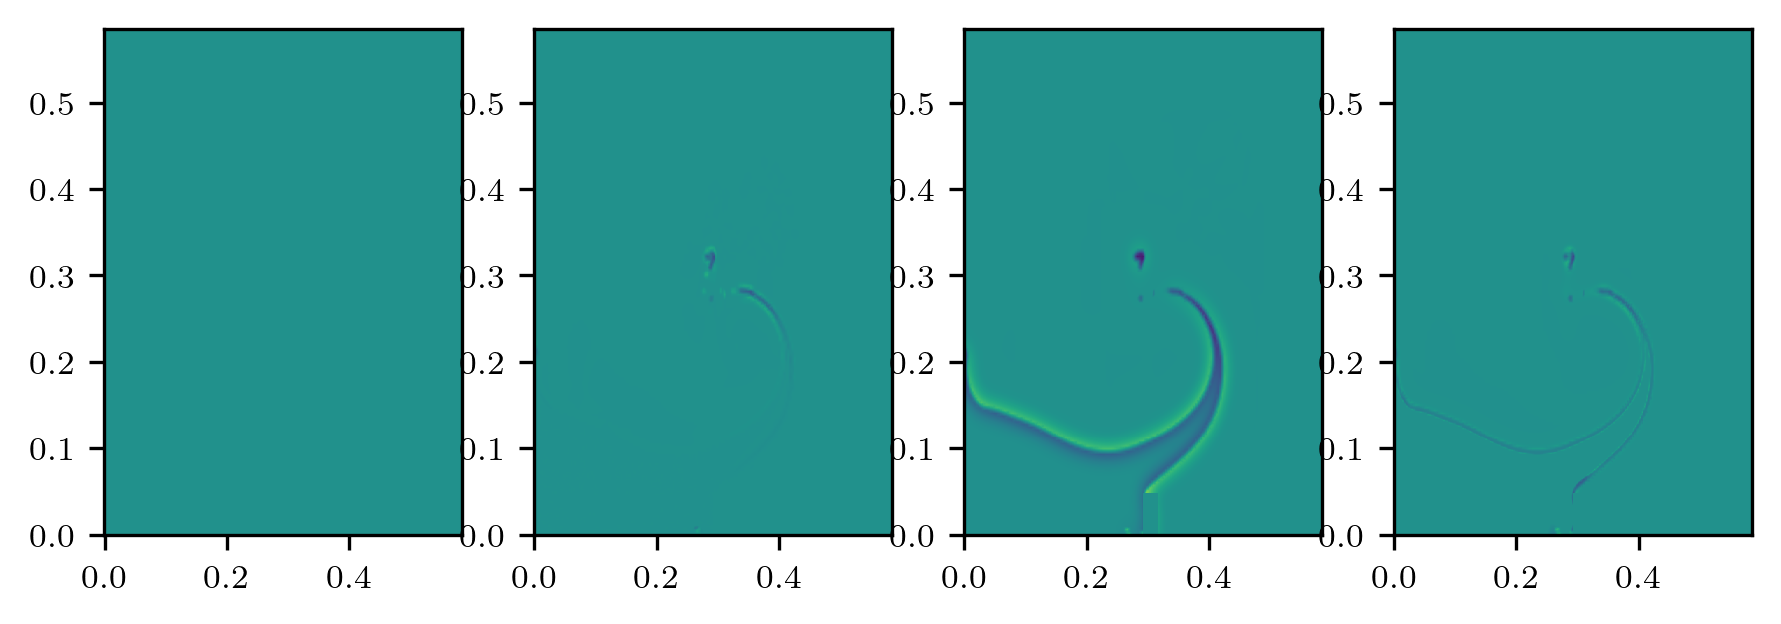

9 0.0 -6.251943407420413e-15 -1.61634347369162e-07 0.0
9 1.0 1.0000000000003073 1.00000018906205 1.0031354427337646
9 33075.45186187069 33076.86269424438 33056.09846602147 33072.67767728557


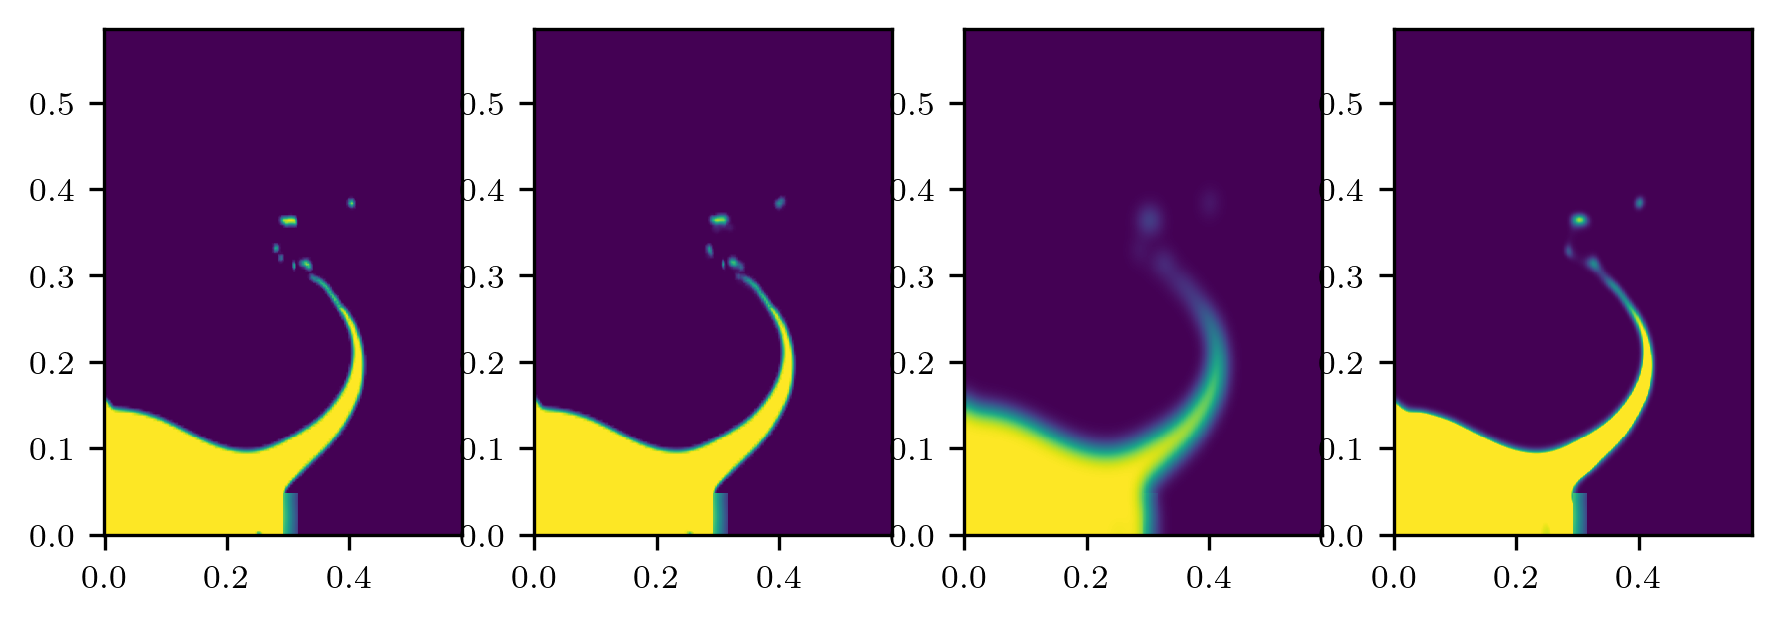

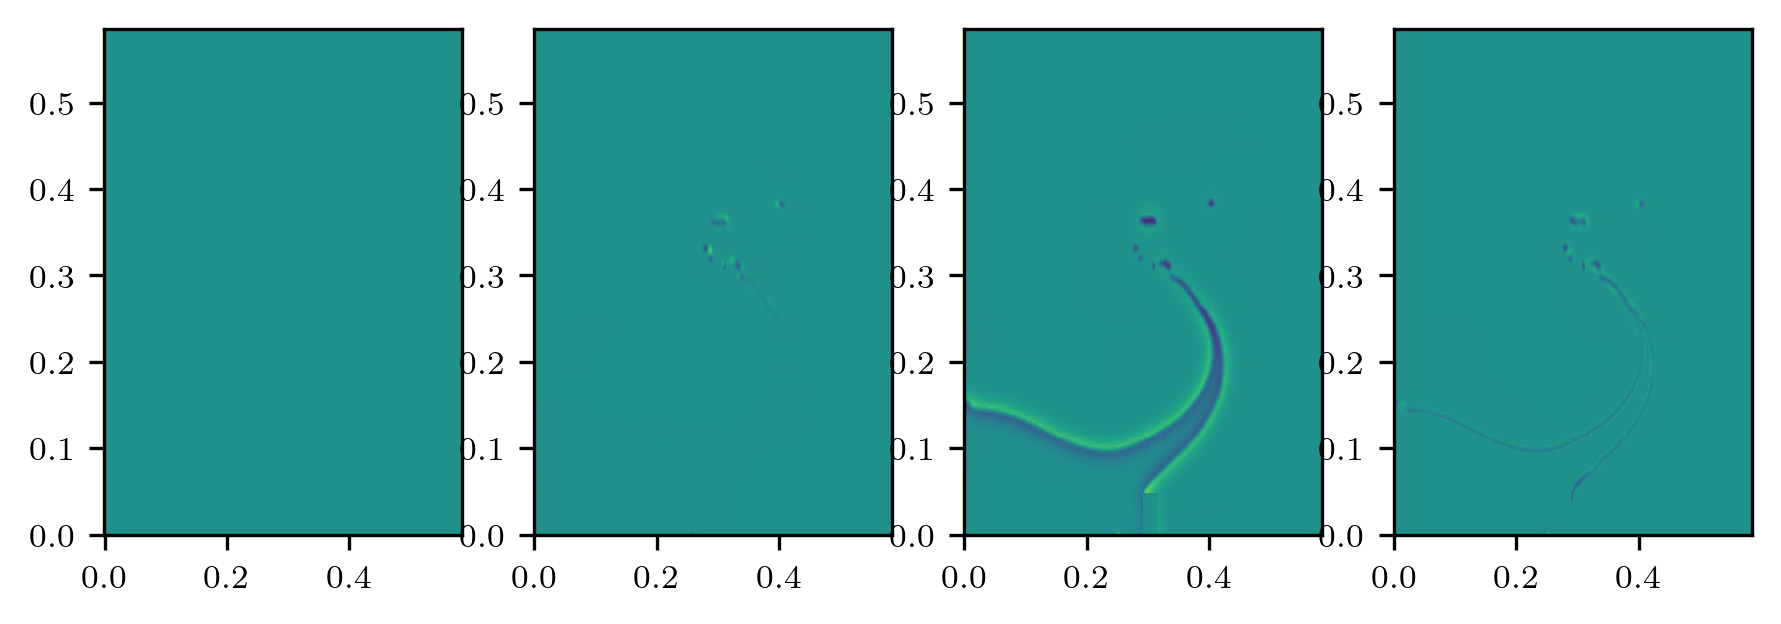

10 0.0 -2.721737765720711e-14 -2.0173093332715334e-07 0.0
10 1.0 1.0000000000001226 1.0000002846276645 1.0027223825454712
10 33113.803145280515 33113.863878801916 33075.037906905265 33085.641187025605


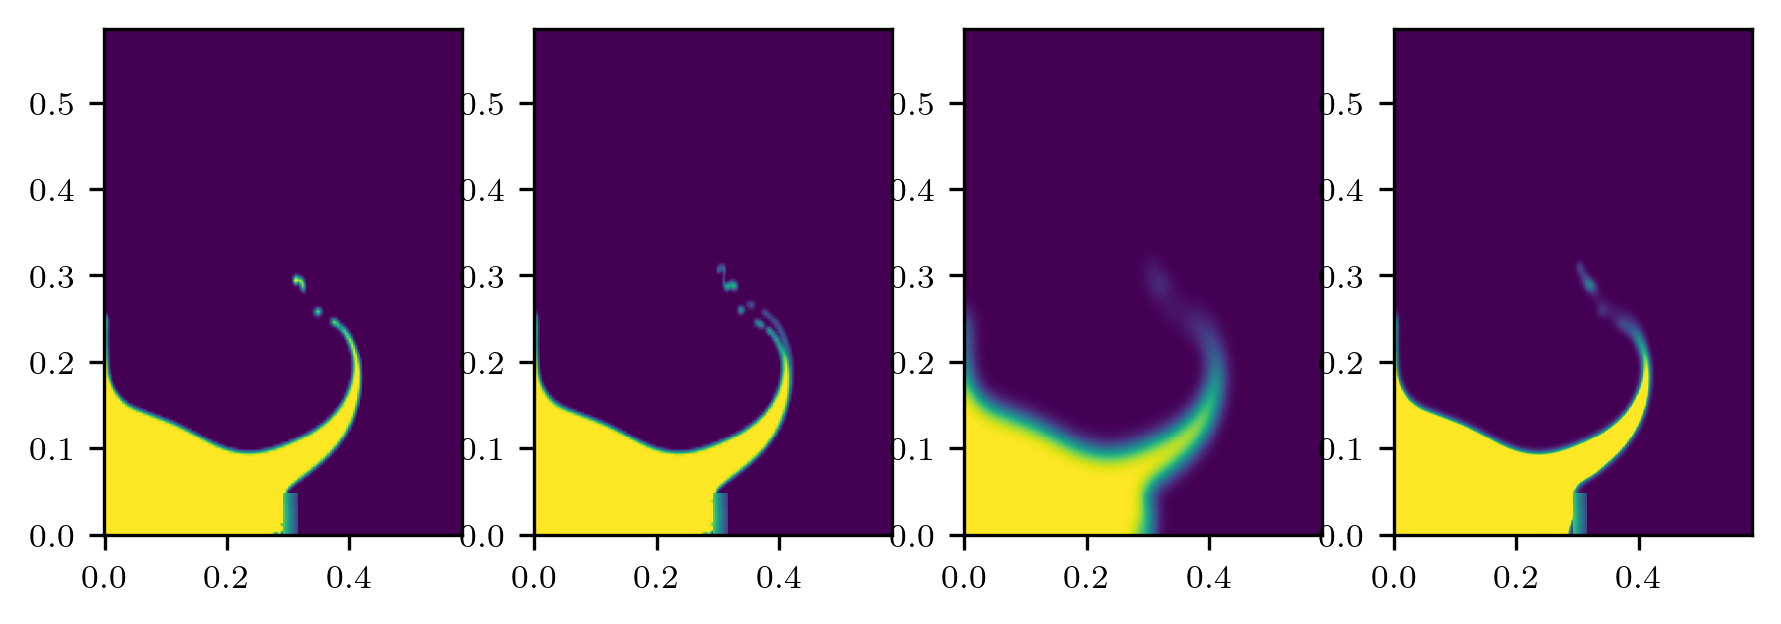

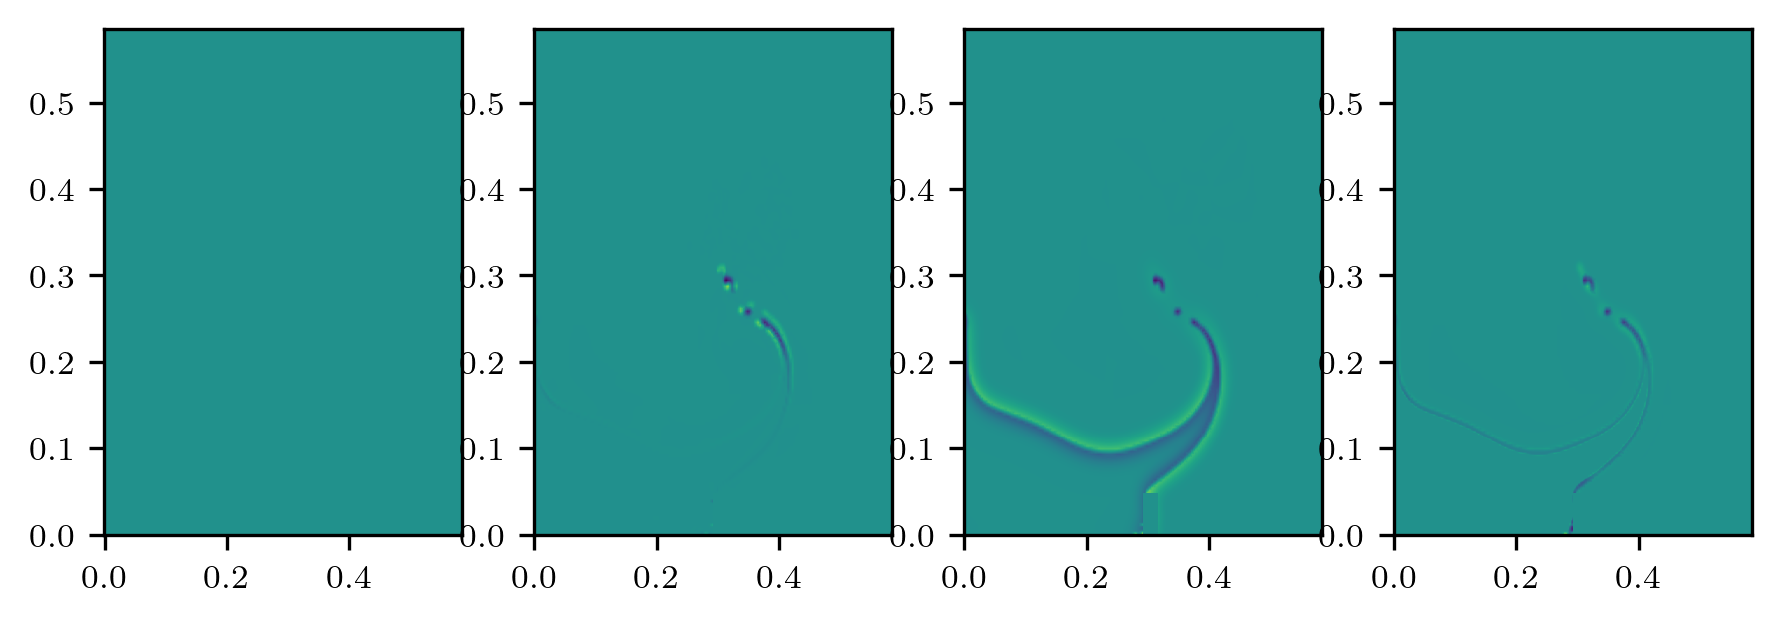

11 0.0 -7.689812328570689e-15 -1.331775928406411e-07 0.0
11 1.0 1.0000000000003333 1.000000202167457 1.0029163360595703
11 33079.204106670564 33081.68411007531 33056.835024013715 33073.02163489203


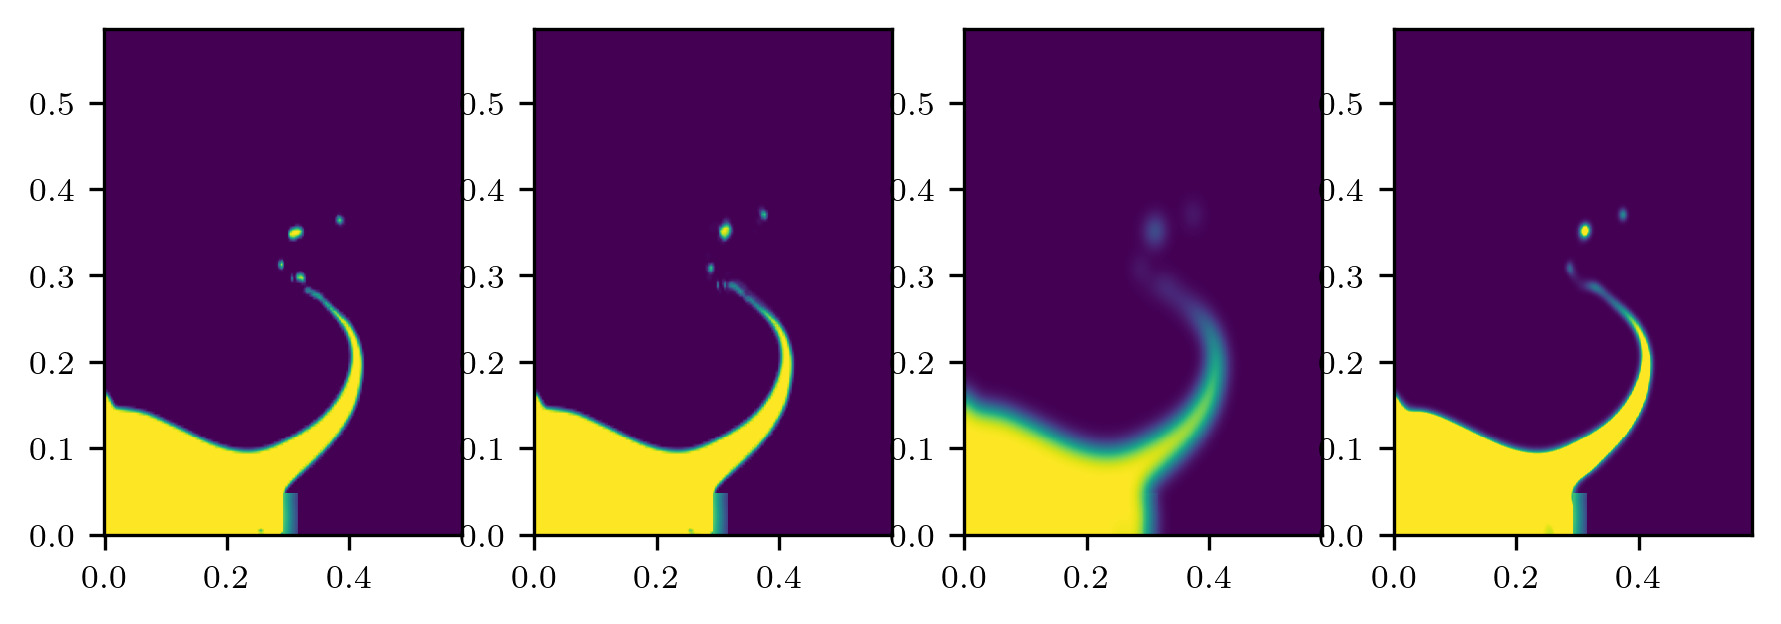

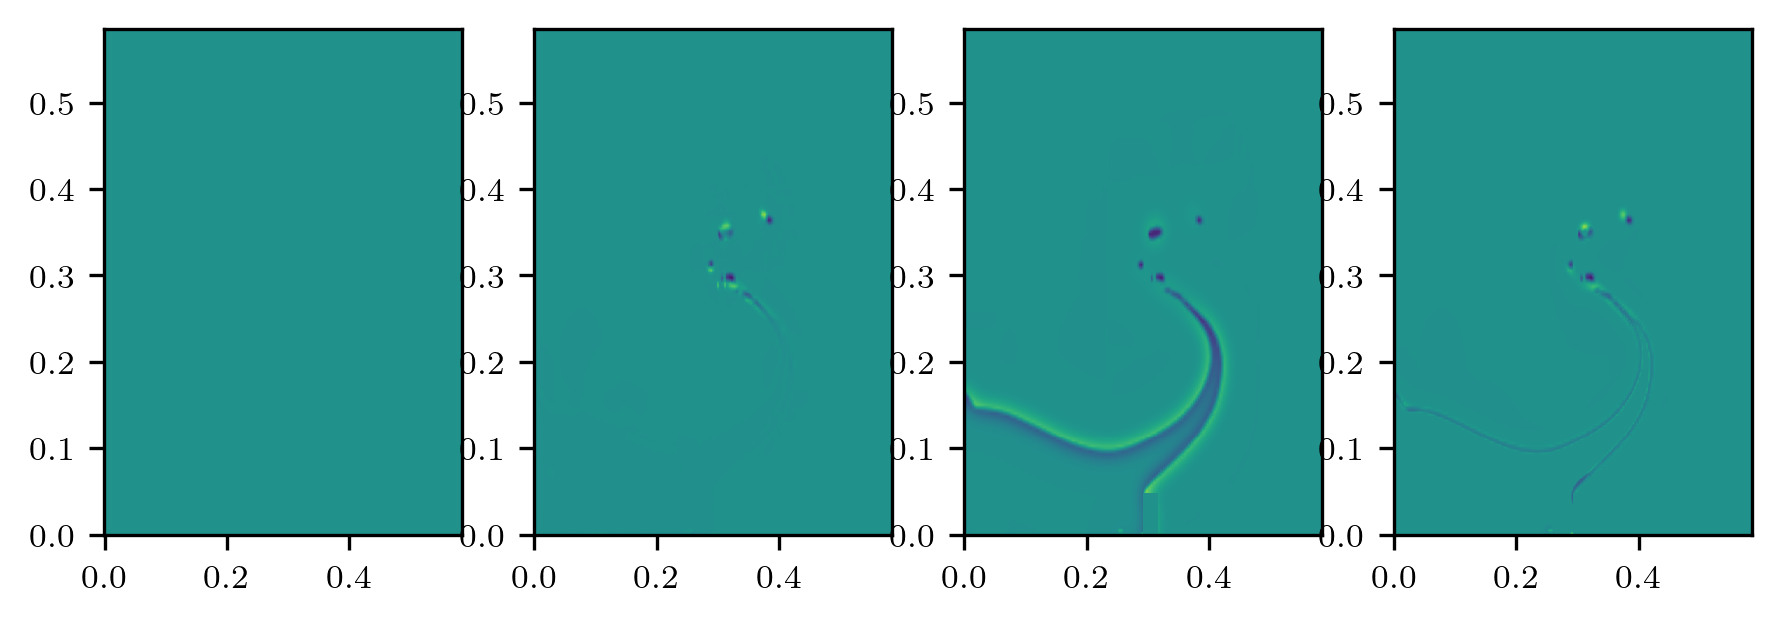

12 0.0 -6.0298988024953815e-15 -1.7658826303661005e-07 0.0
12 1.0 1.0000000000003133 0.9999998848289232 1.0031481981277466
12 33075.56527982388 33076.84430225197 33056.32165142203 33072.870473002404


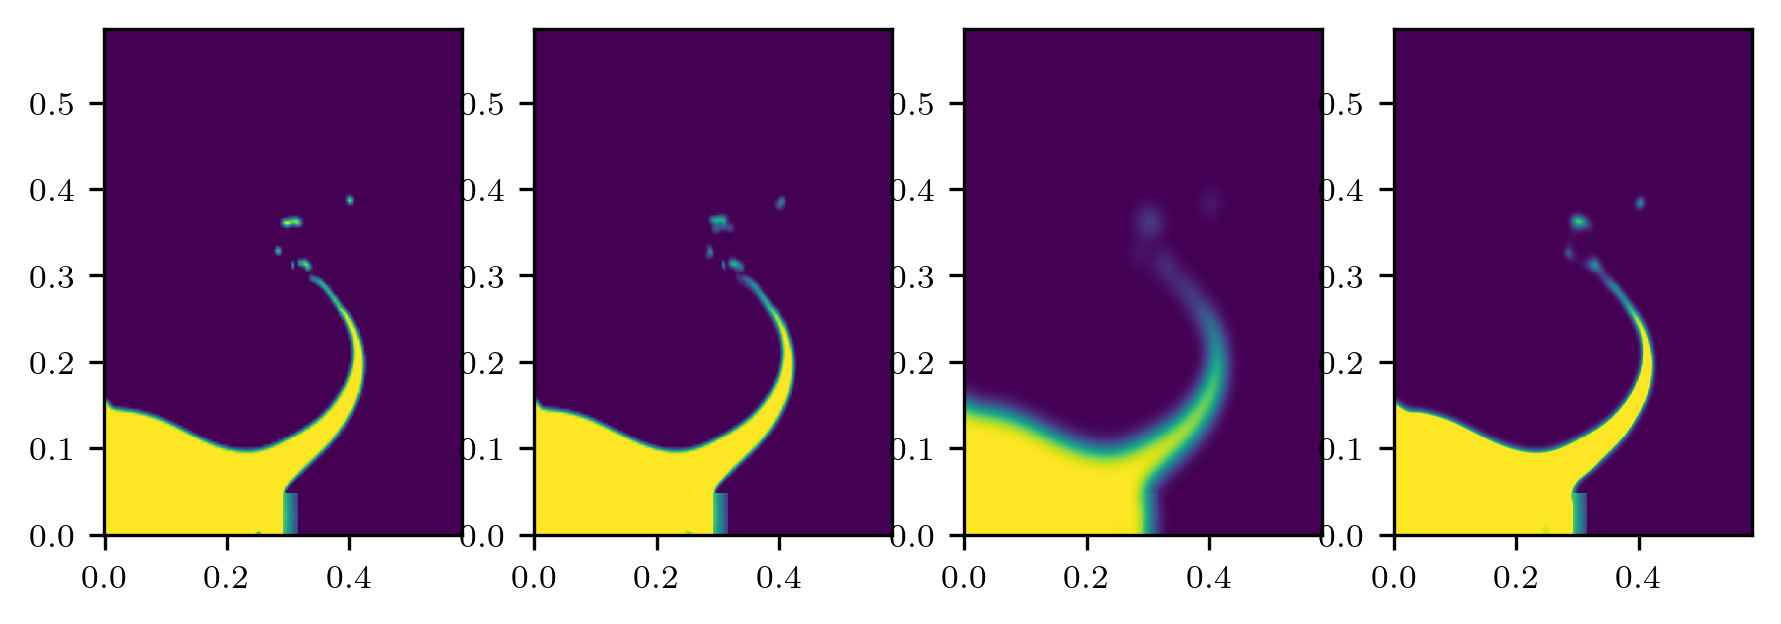

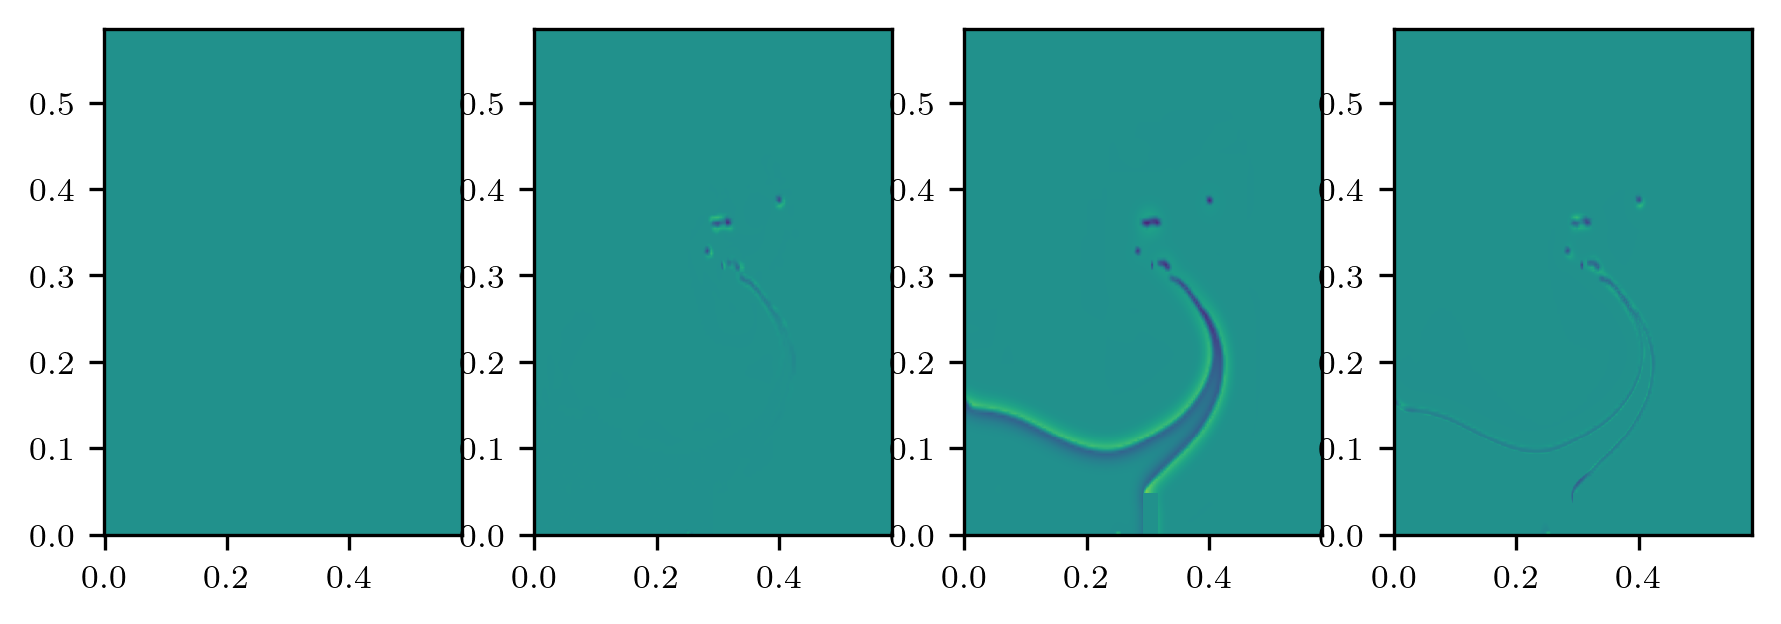

13 0.0 -2.597574932927671e-14 -2.0848121667406145e-07 0.0
13 1.0 1.0000000000000973 0.9999998866551811 1.0028176307678223
13 33106.8968101142 33104.45372846201 33075.530366995 33095.09951128258


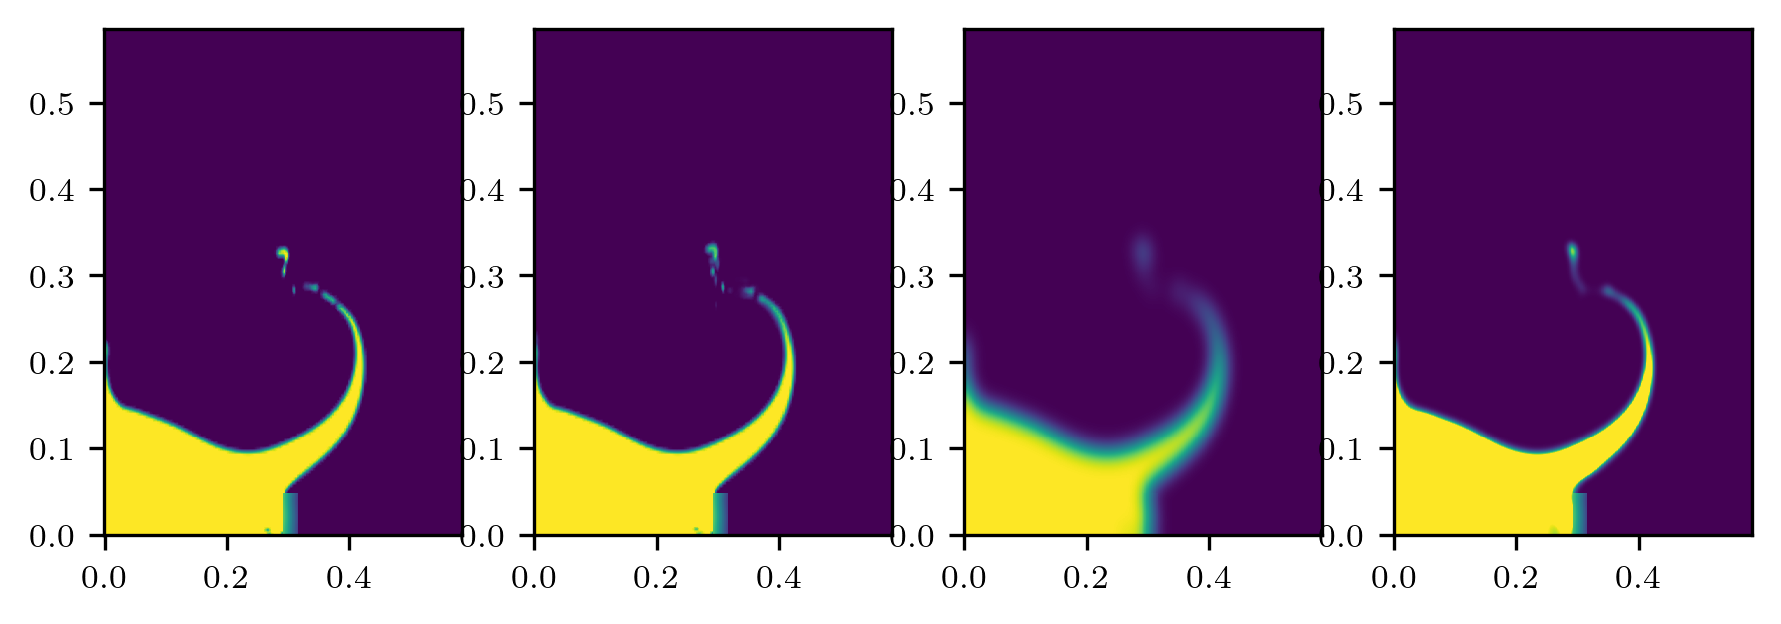

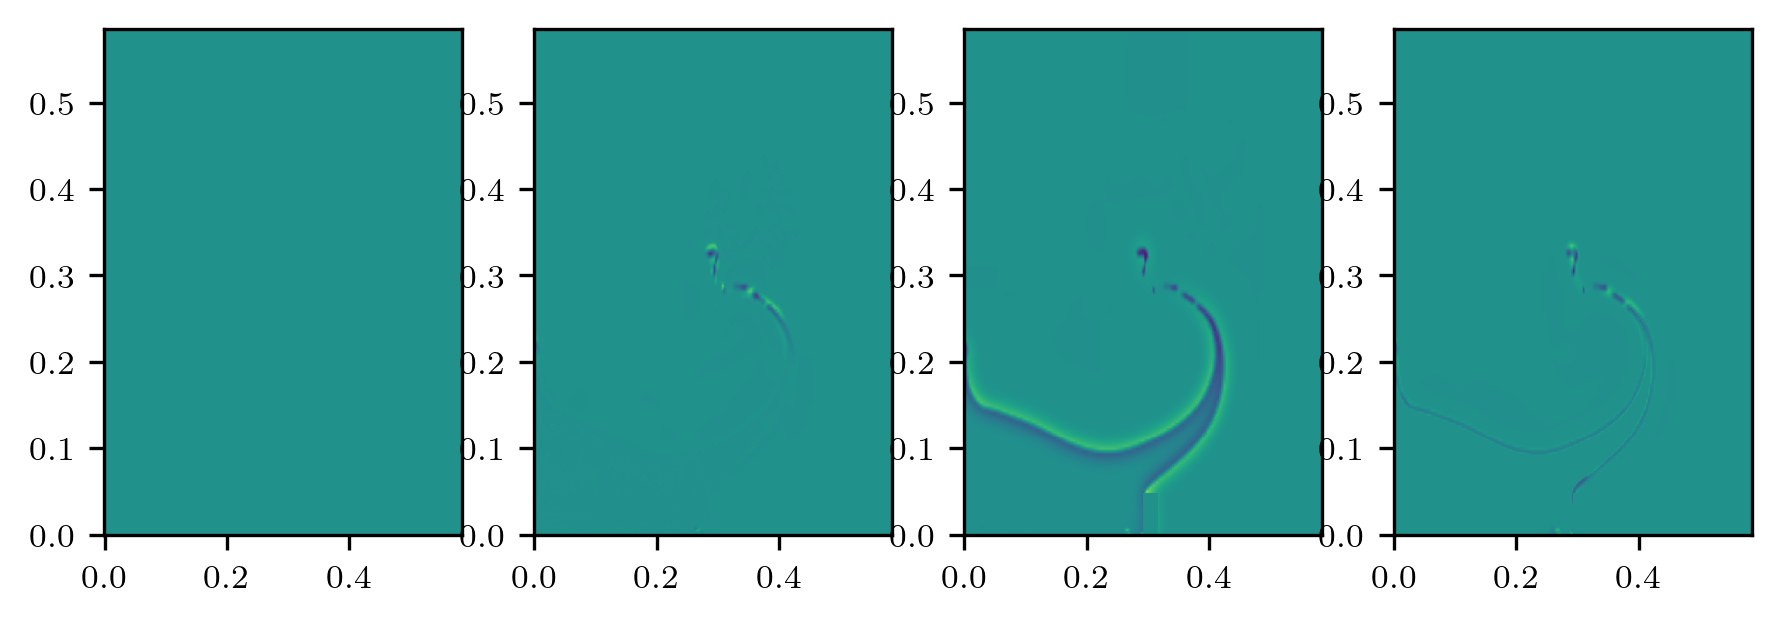

14 0.0 -1.8041124150158794e-14 -1.7150396436765587e-07 0.0
14 1.0 1.0000000000002534 1.000000041729664 1.0031423568725586
14 33079.241422805026 33077.50743873564 33056.80325169479 33073.88160905657


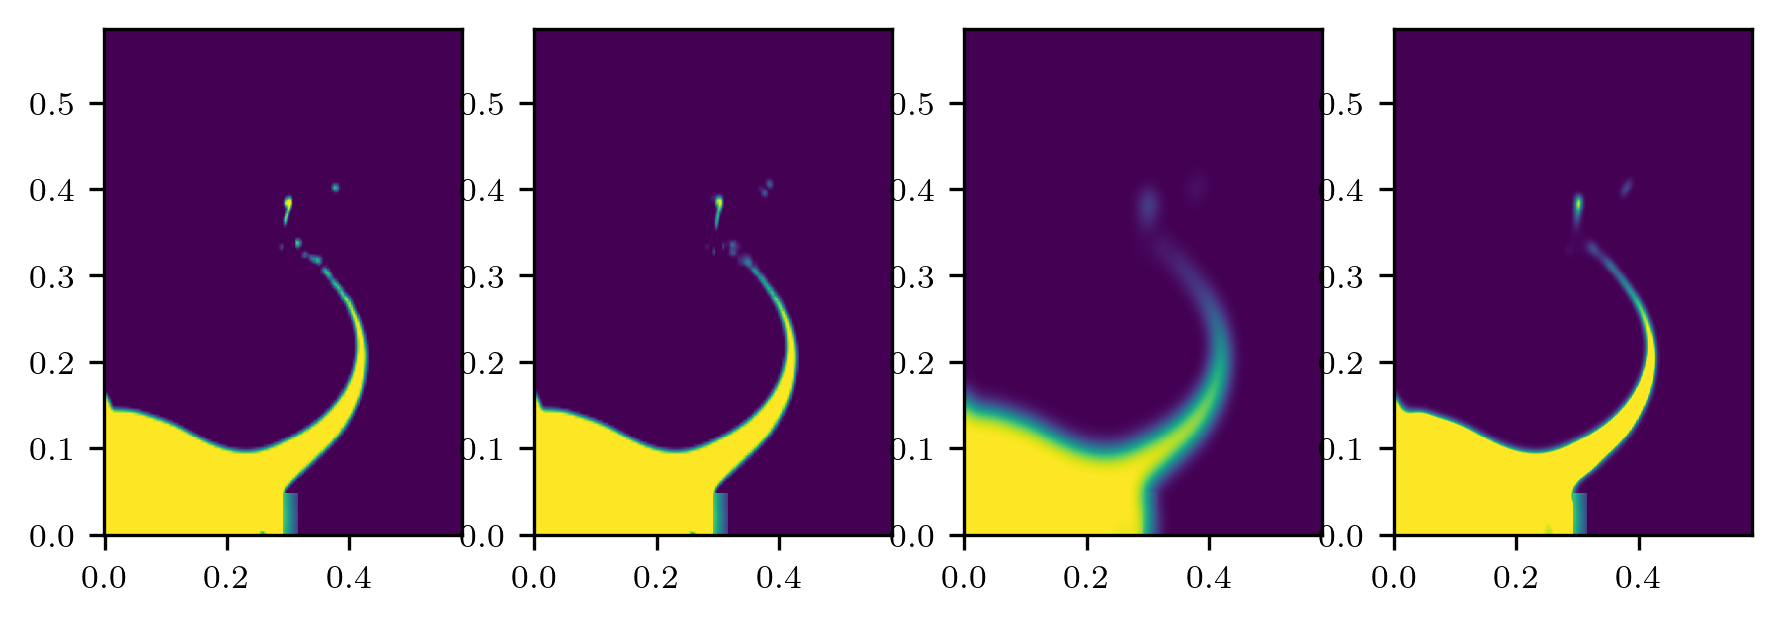

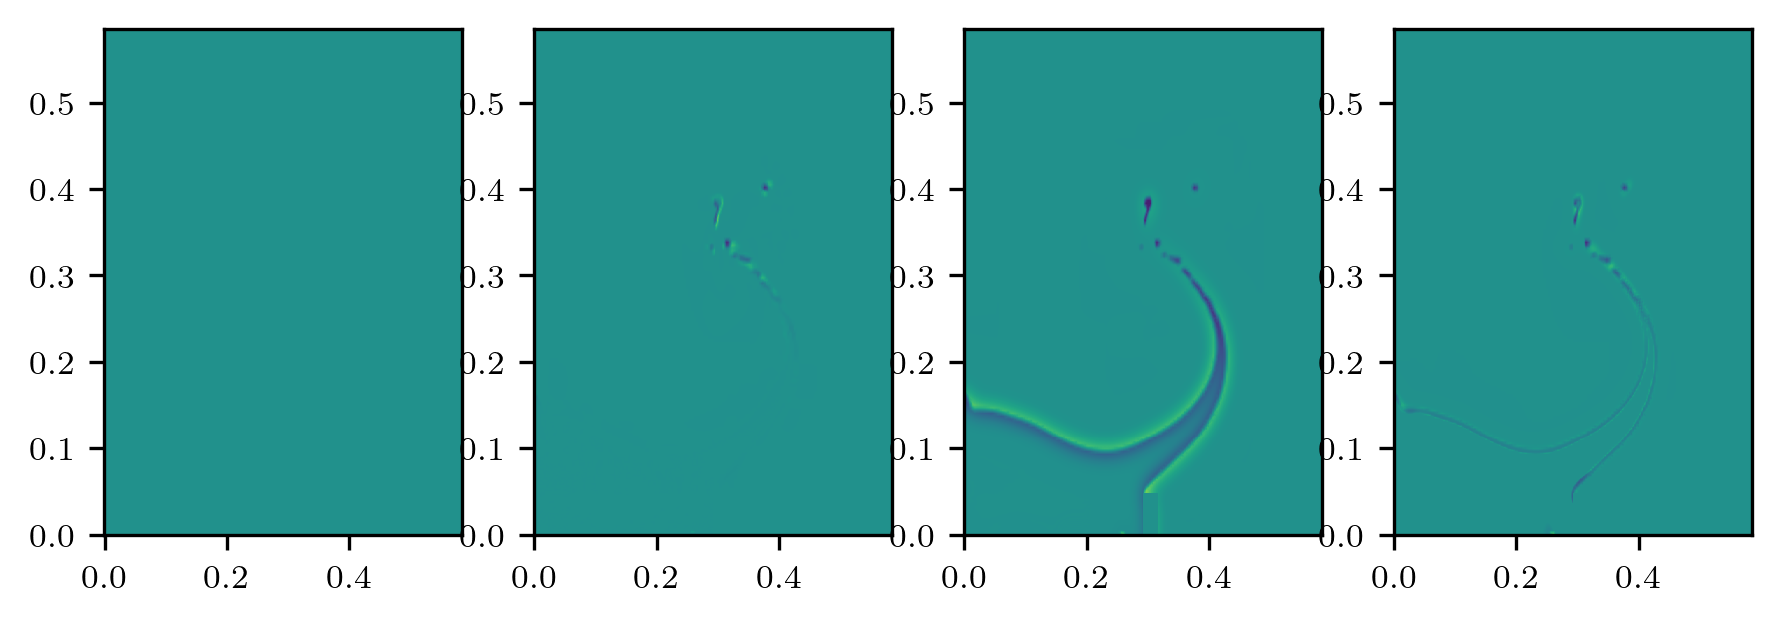

15 0.0 -2.5158694572091633e-14 -2.1635886013244864e-07 0.0
15 1.0 1.0000000000001106 0.9999999534115354 1.0028666257858276
15 33098.62189134409 33096.89159076379 33058.91520651585 33062.098525361005


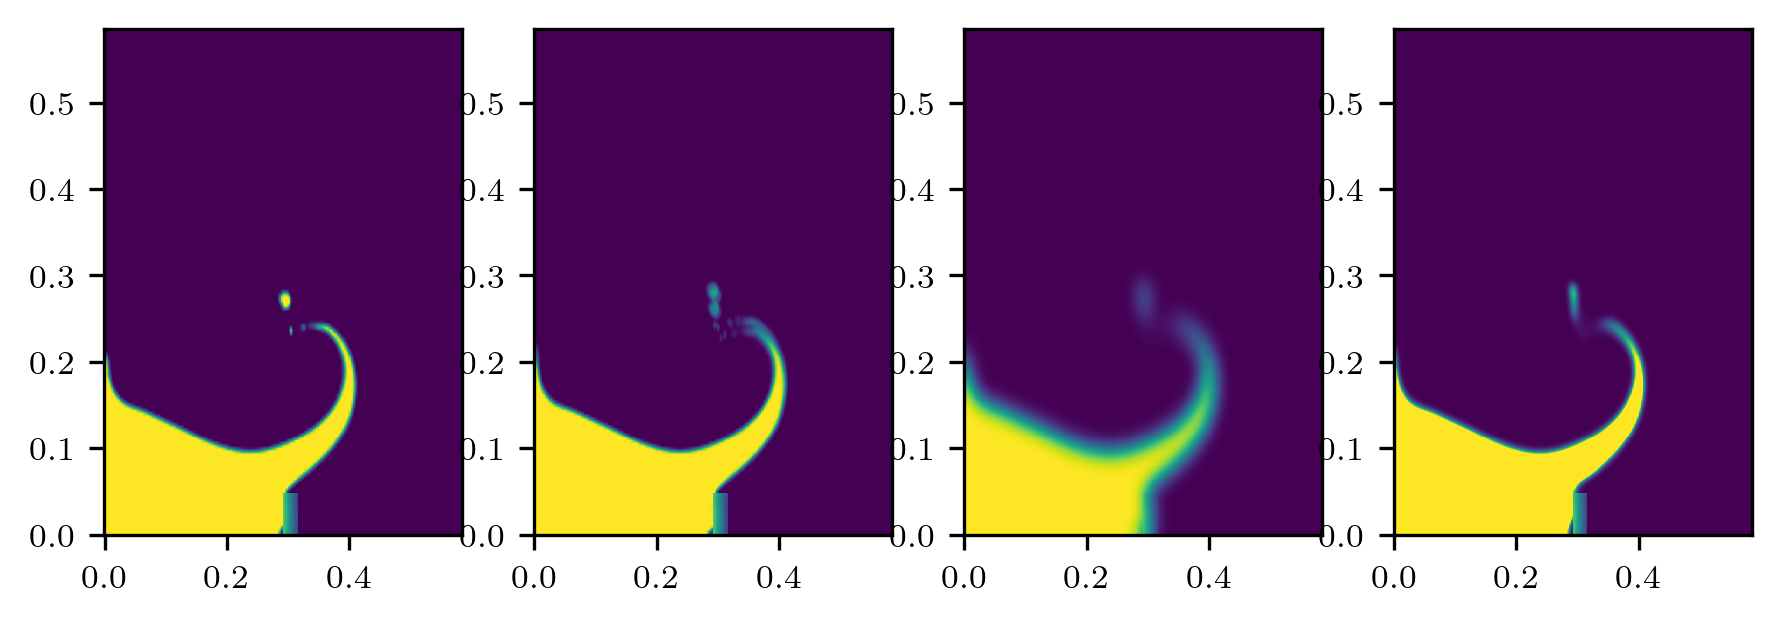

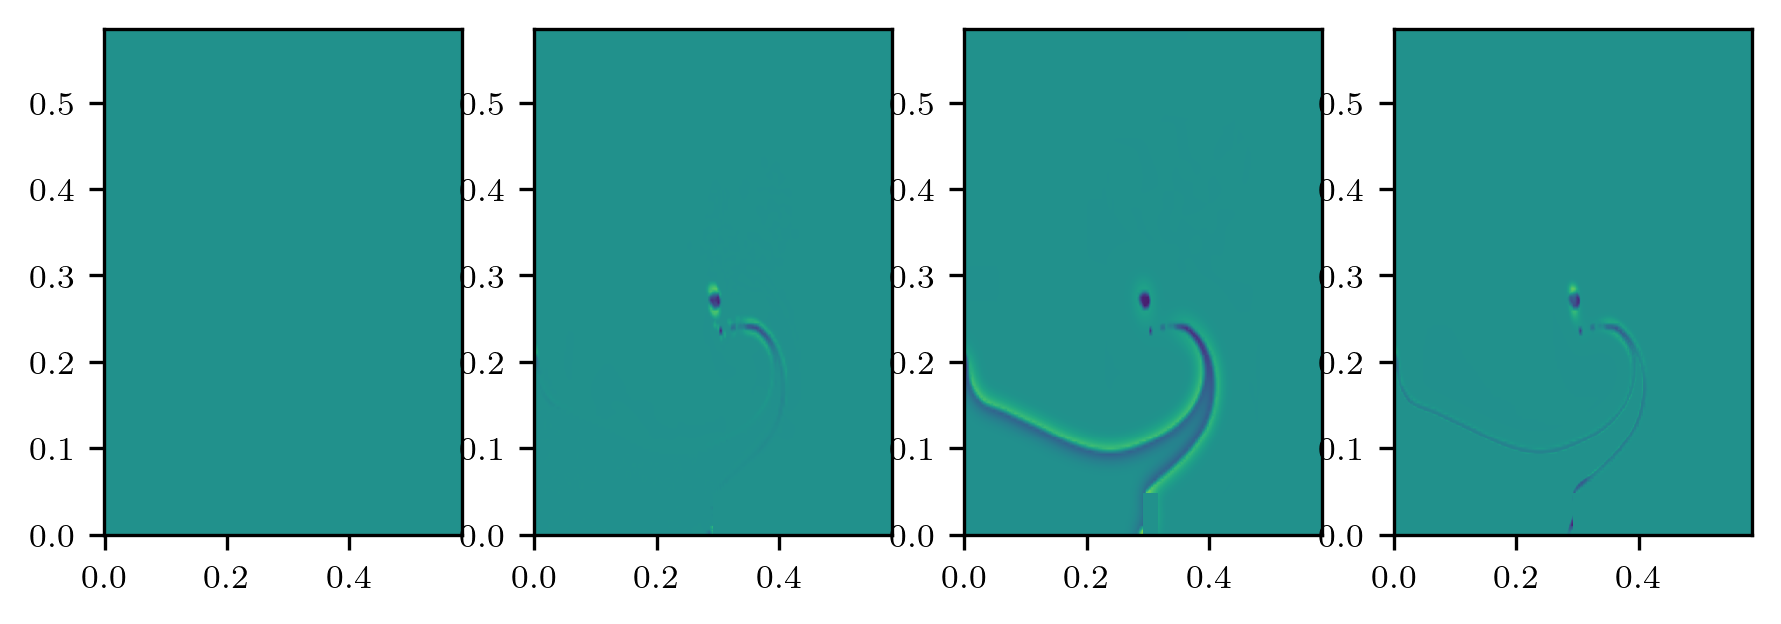

16 0.0 -7.228592724395355e-15 -2.9663683573891993e-07 0.0
16 1.0 1.0000000000002611 1.0000005119390523 1.0030125379562378
16 33077.631897367464 33078.86616818283 33056.50823713708 33072.072853413345


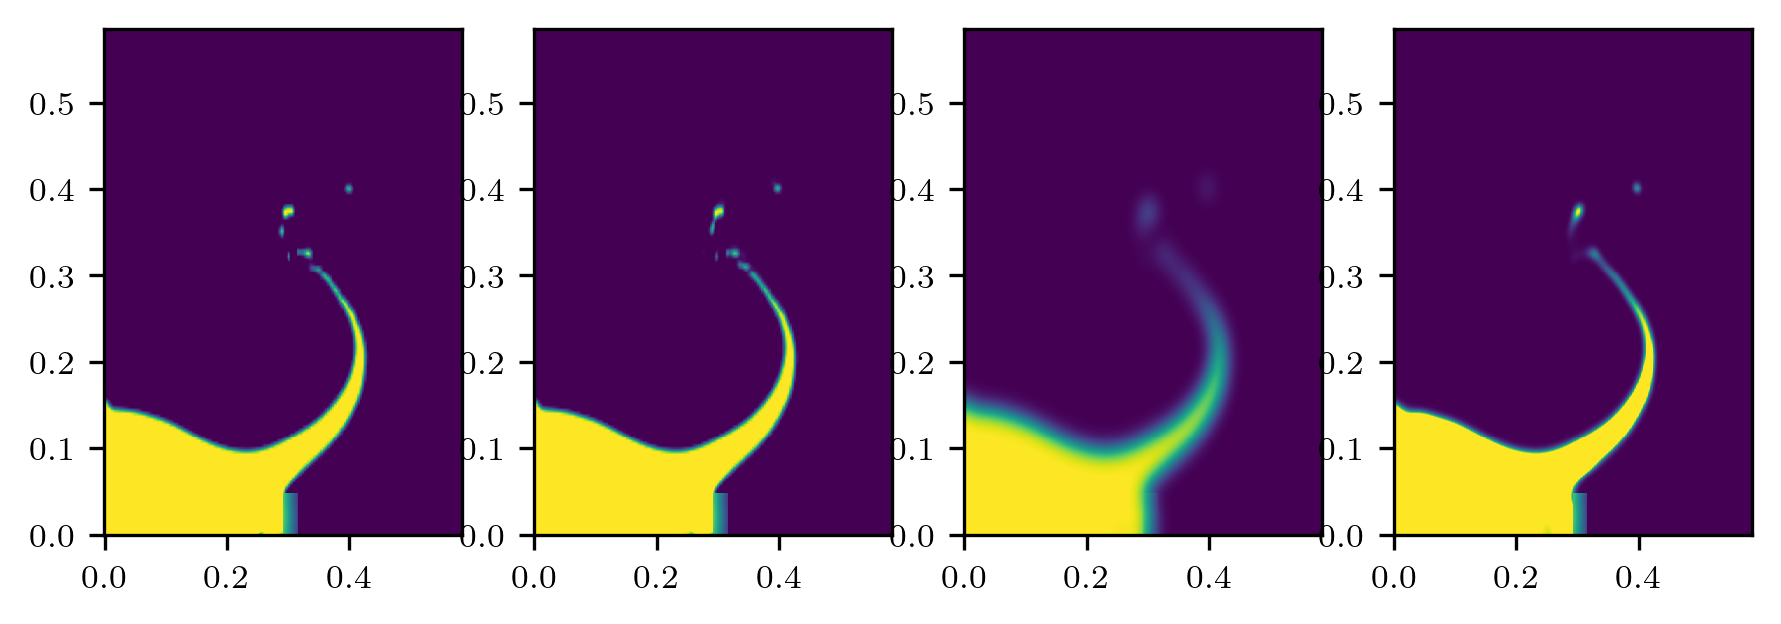

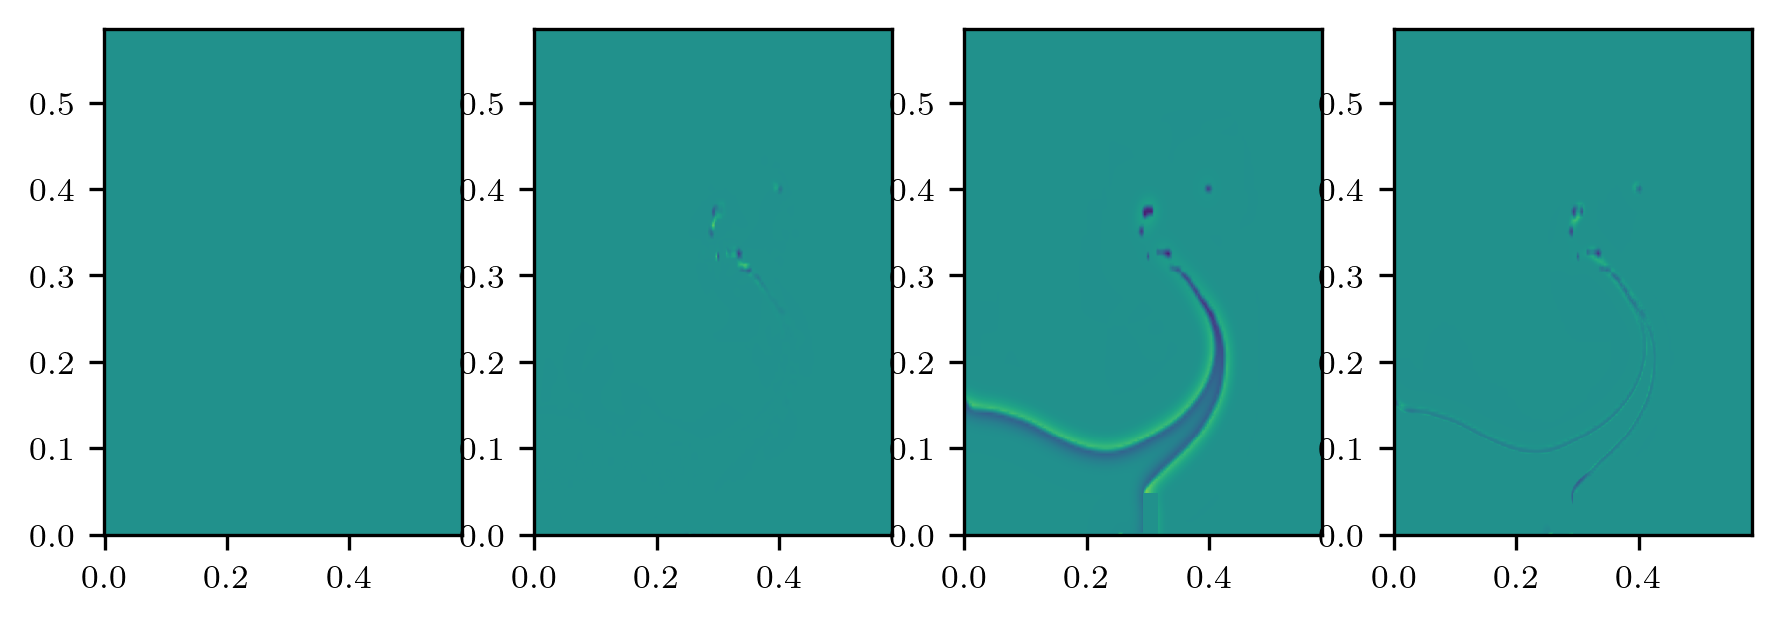

17 0.0 -2.314554797822055e-15 -2.1476267250290565e-07 0.0
17 1.0 1.0000000000002816 0.999999981022173 1.0032340288162231
17 33076.31528615486 33075.17302022908 33056.223738798304 33071.91361055301


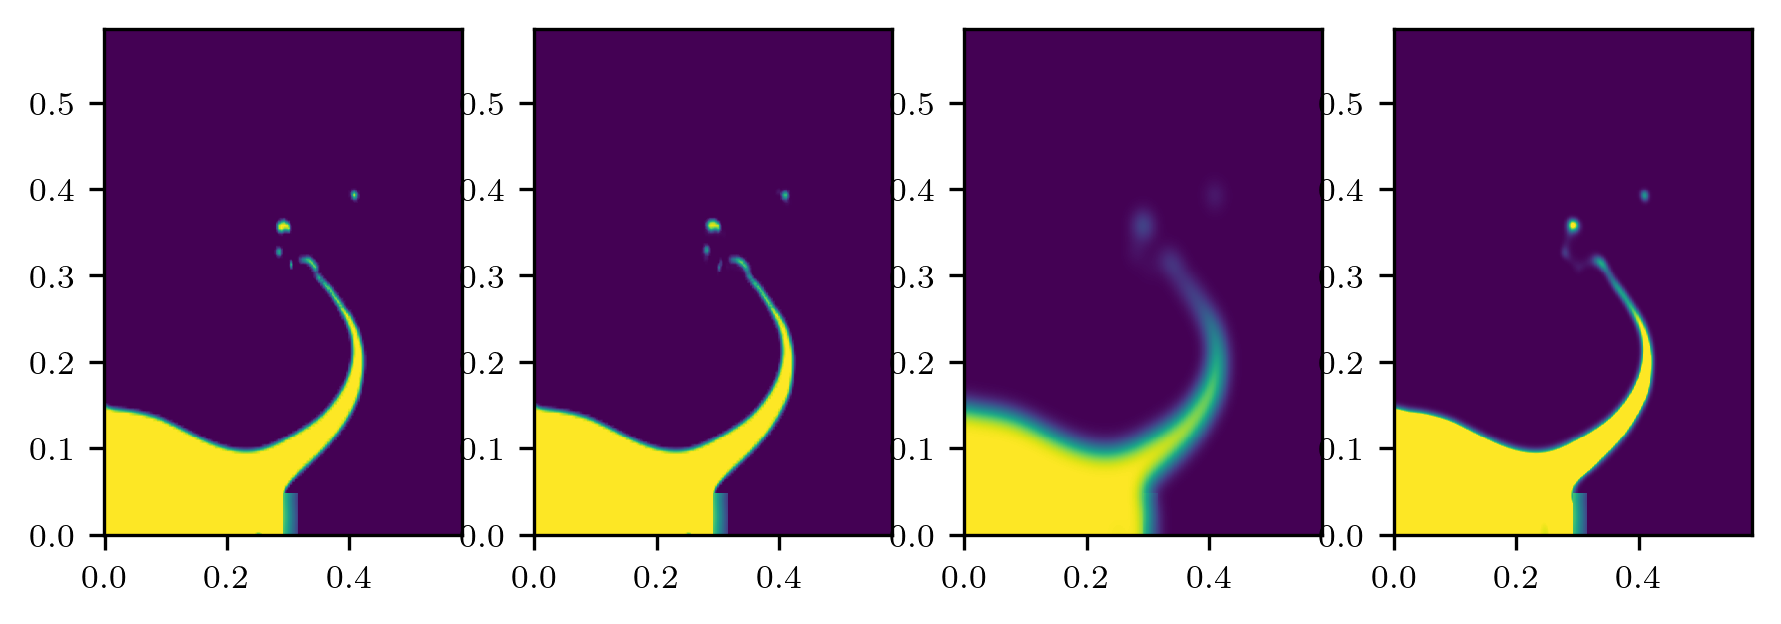

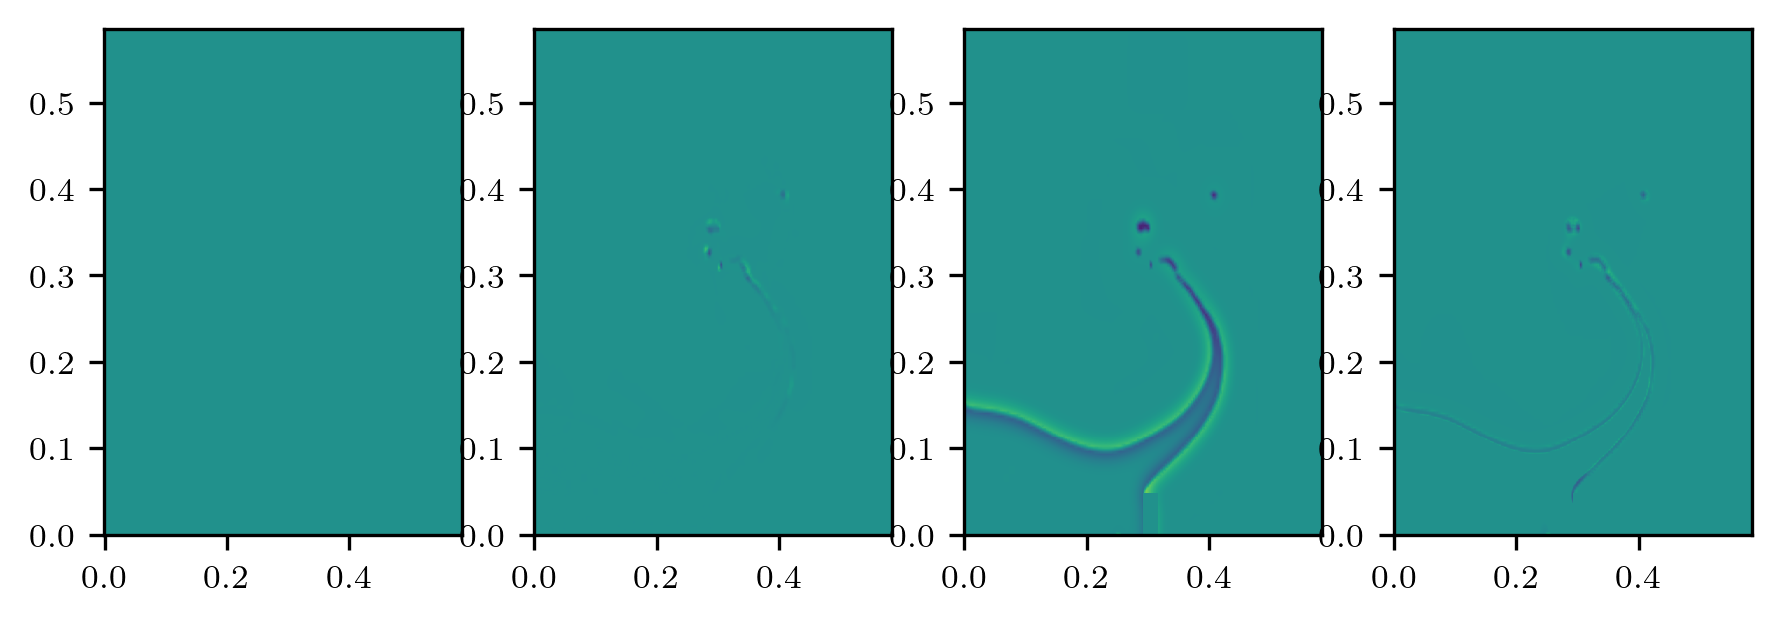

18 0.0 -1.8127860323957634e-14 -2.1484898317662877e-07 0.0
18 1.0 1.000000000000254 1.0000002082877661 1.0031076669692993
18 33079.27106861258 33076.797735073036 33055.44971586667 33072.19516163473


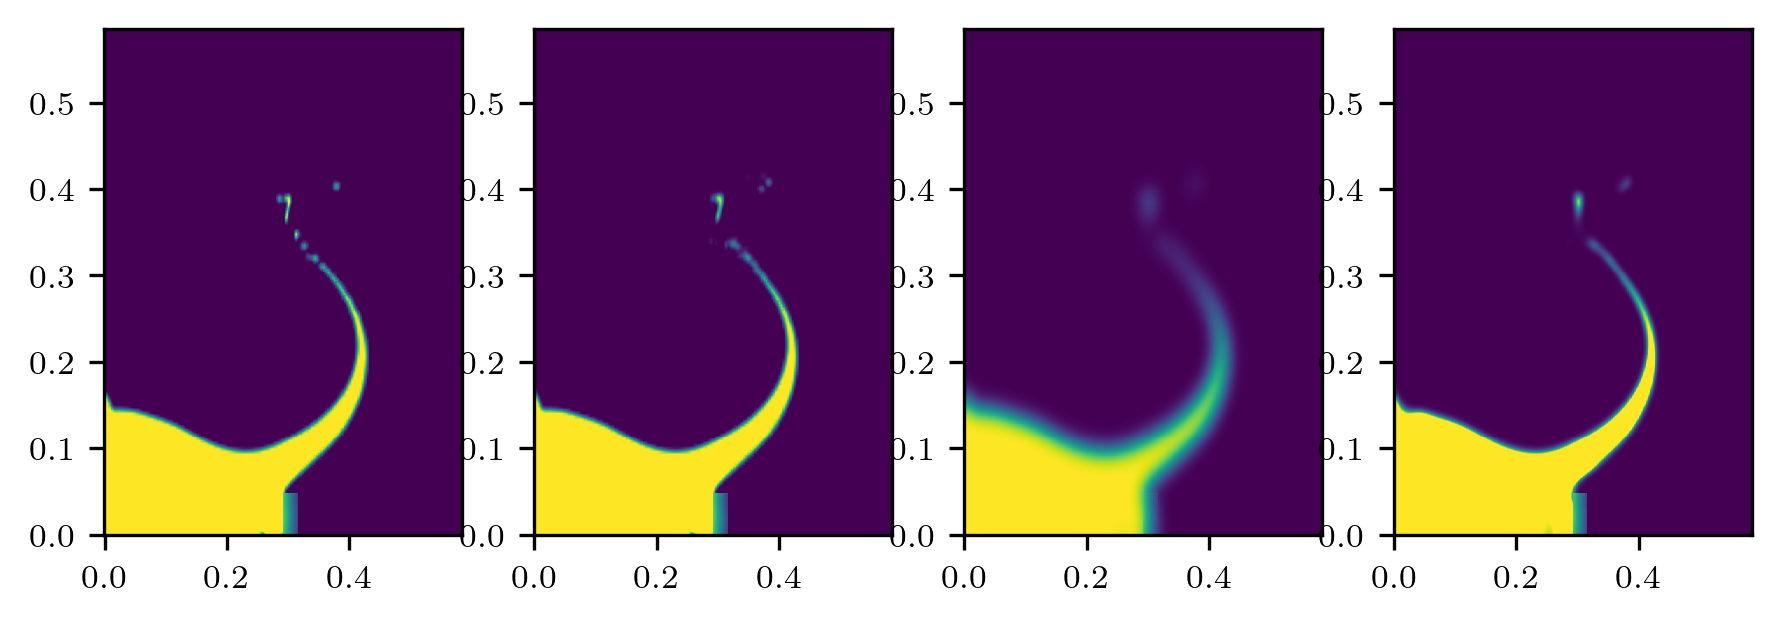

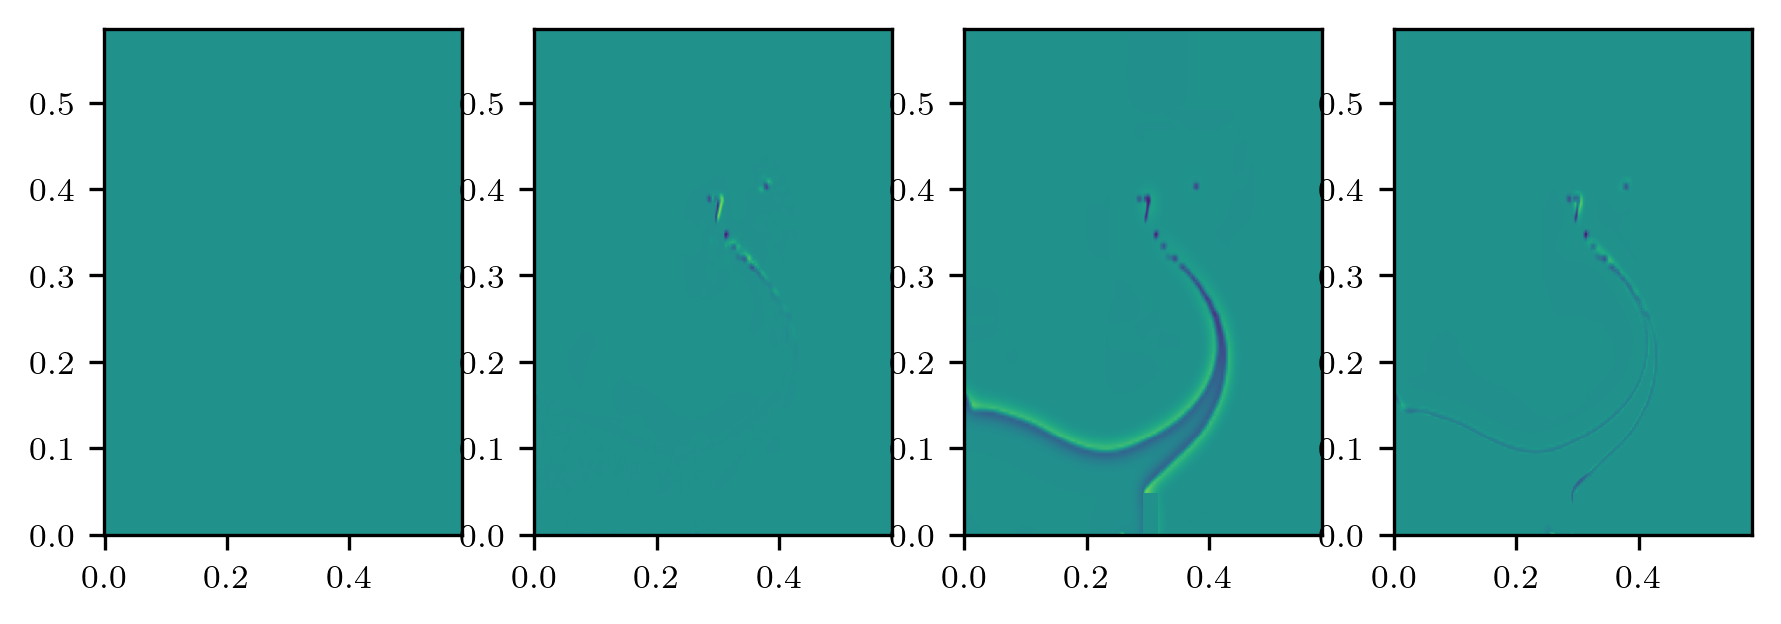

19 0.0 -2.355754480376504e-14 -2.2186648351941248e-07 0.0
19 1.0 1.0000000000001201 0.9999993772626399 1.0029805898666382
19 33088.01466844628 33089.284829623604 33047.20279245638 33044.83003410841


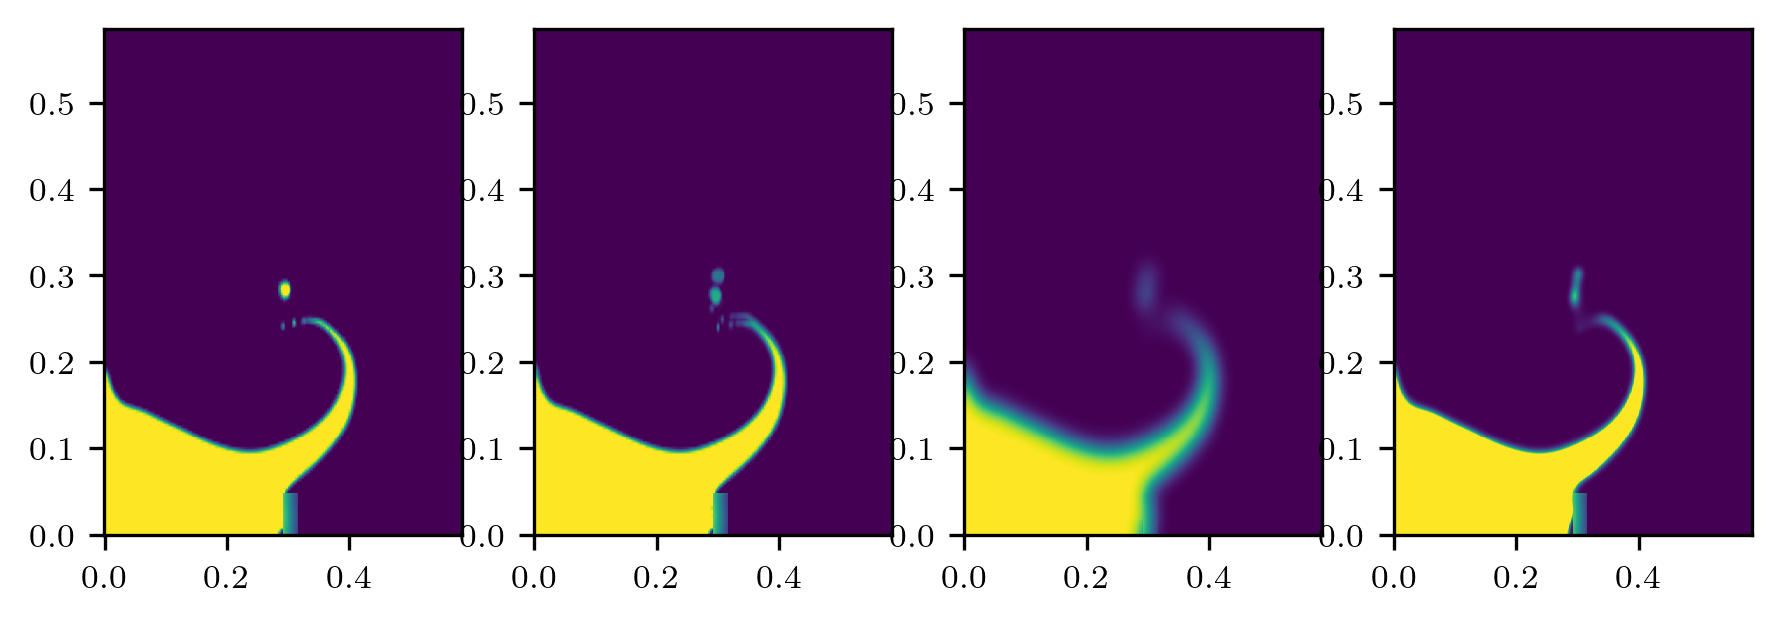

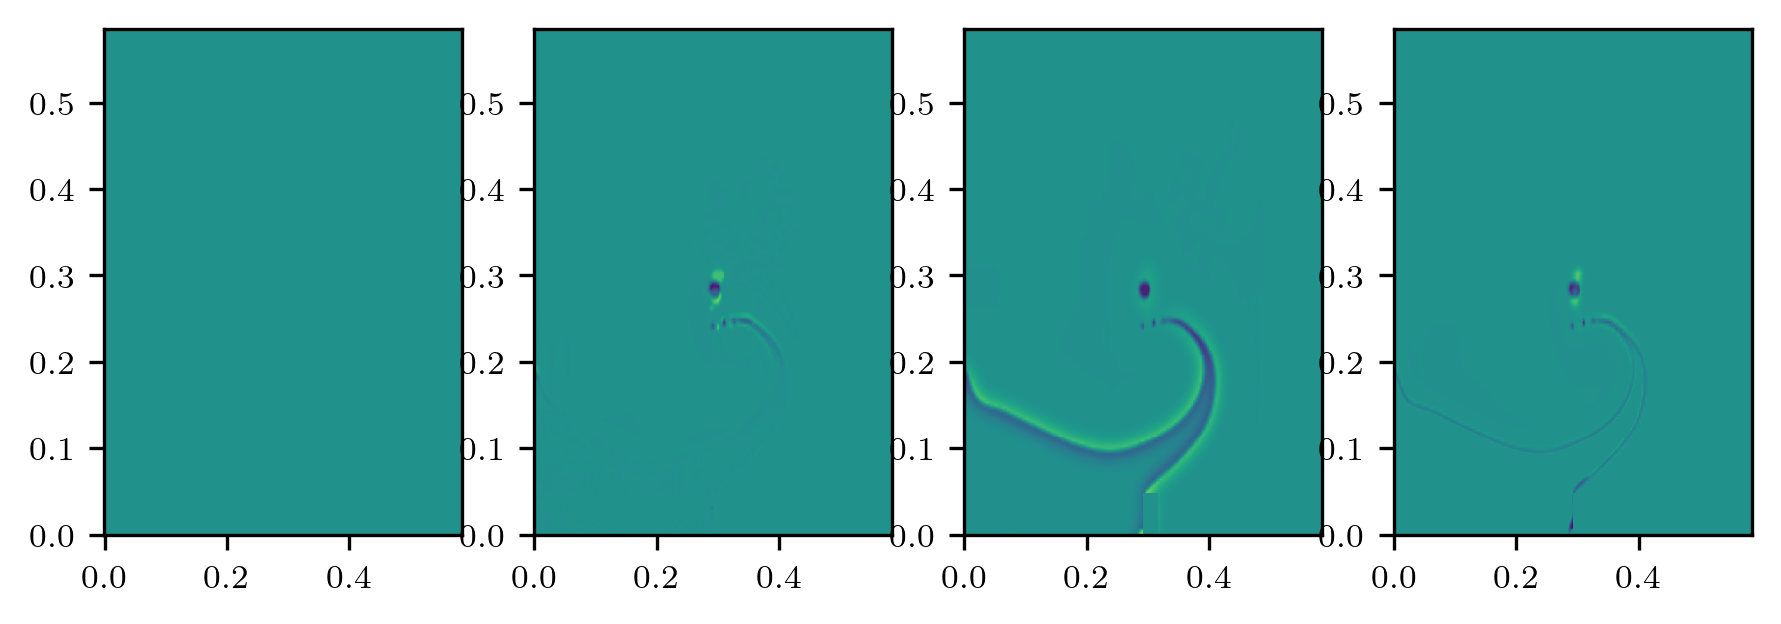

In [21]:
i = 16
for i in range(20):
    print(i, np.min(X_test_grid[i]), np.min(X_test_ROM[i]), np.min(X_test_sROM[i]), np.min(X_test_sROMs[i]))
    print(i, np.max(X_test_grid[i]), np.max(X_test_ROM[i]), np.max(X_test_sROM[i]), np.max(X_test_sROMs[i]))
    print(i, np.sum(X_test_grid[i]), np.sum(X_test_ROM[i]), np.sum(X_test_sROM[i]), np.sum(X_test_sROMs[i]))
    fig,axs = plt.subplots(1, 4, figsize=(single_column_in*2, single_column_in/1.618))
    axs[0].pcolormesh(X, Y, X_test_grid[i].reshape(case["shape"]))
    axs[1].pcolormesh(X, Y, X_test_ROM[i].reshape(case["shape"]))
    axs[2].pcolormesh(X, Y, X_test_sROM[i].reshape(case["shape"]))
    axs[3].pcolormesh(X, Y, X_test_sROMs[i].reshape(case["shape"]))
    plt.show()
    fig,axs = plt.subplots(1, 4, figsize=(single_column_in*2, single_column_in/1.618))
    axs[0].pcolormesh(X, Y, (X_test_grid[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[1].pcolormesh(X, Y, (X_test_ROM[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[2].pcolormesh(X, Y, (X_test_sROM[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[3].pcolormesh(X, Y, (X_test_sROMs[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    plt.show()